# Compute-Optimal Tiny Transformers
The pipeline does five things:
1. prepares byte-level train/validation/test arrays from raw text,
2. builds an iso-compute sweep over small GPT-like models,
3. trains every run in the sweep,
4. aggregates results across seeds and schedule regimes,
5. fits simple scaling curves and saves the resulting plots.

In [1]:
!pip install -r requirements.txt

### Datset Download

In [2]:
from pathlib import Path
from datasets import load_dataset

out_dir = Path("data/wikitext103_raw")
out_dir.mkdir(parents=True, exist_ok=True)

ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")

split_to_file = {
    "train": "train.txt",
    "validation": "valid.txt",
    "test": "test.txt",
}

for split, filename in split_to_file.items():
    with open(out_dir / filename, "w", encoding="utf-8") as f:
        for row in ds[split]:
            text = row["text"]
            if text is not None:
                f.write(text.rstrip("\n") + "\n")

print("Wrote:")
for filename in split_to_file.values():
    print(" -", out_dir / filename)

Wrote:
 - data/wikitext103_raw/train.txt
 - data/wikitext103_raw/valid.txt
 - data/wikitext103_raw/test.txt


### Start

In [ ]:
from copy import deepcopy
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display
from compute_optimal.analysis import run_analysis
from compute_optimal.data import prepare_dataset
from compute_optimal.planner import build_sweep_plan
from compute_optimal.train import train_single_run
from compute_optimal.utils import ensure_dir, load_yaml, resolve_path

PROJECT_ROOT = "/home/jovyan/persisted_storage/JHU Courses/RESEARCH PROJECTS/Advanced Applied ML"
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/jovyan/persisted_storage/JHU Courses/RESEARCH PROJECTS/Advanced Applied ML


## Load config
`configs/main.yaml` is the run im working with.

In [4]:
CONFIG_NAME = "main.yaml"
OVERWRITE = False      # Set True to retrain runs even if outputs already exist
ANALYSIS_ONLY = False  # Set True to skip training and only rebuild CSVs/plots
RUN_FIRST_N = None     # Example: 2 to run only the first 2 planned runs while debugging

config_path = PROJECT_ROOT + "/configs/" + CONFIG_NAME
base_cfg = load_yaml(config_path)
cfg = deepcopy(base_cfg)

OUT_ROOT = ensure_dir(resolve_path(cfg["experiment"]["out_dir"]))
resolved_config_path = OUT_ROOT / "resolved_config_notebook.yaml"
with open(resolved_config_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

display(Markdown(f"**Resolved output directory:** `{OUT_ROOT}`"))
display(Markdown(f"**Resolved config snapshot:** `{resolved_config_path}`"))
print(yaml.safe_dump(cfg, sort_keys=False))

**Resolved output directory:** `/home/jovyan/persisted_storage/JHU Courses/RESEARCH PROJECTS/Advanced Applied ML/outputs/main_v2`

**Resolved config snapshot:** `/home/jovyan/persisted_storage/JHU Courses/RESEARCH PROJECTS/Advanced Applied ML/outputs/main_v2/resolved_config_notebook.yaml`

experiment:
  name: main_v2
  out_dir: outputs/main_v2
  device: auto
  cpu_num_threads: 1
  seeds:
  - 0
  - 1
  - 2
  schedule_regimes:
  - matched
  - fixed
data:
  source_dir: data/wikitext103_raw
  prepared_dir: outputs/main_v2/prepared_data
  train_file: train.txt
  valid_file: valid.txt
  test_file: test.txt
  overwrite_prepared: false
model_grid:
- name: gpt_2l_16d
  n_layer: 2
  n_head: 4
  n_embd: 16
  mlp_ratio: 4.0
- name: gpt_2l_20d
  n_layer: 2
  n_head: 4
  n_embd: 20
  mlp_ratio: 4.0
- name: gpt_2l_24d
  n_layer: 2
  n_head: 4
  n_embd: 24
  mlp_ratio: 4.0
- name: gpt_2l_28d
  n_layer: 2
  n_head: 4
  n_embd: 28
  mlp_ratio: 4.0
- name: gpt_2l_32d
  n_layer: 2
  n_head: 4
  n_embd: 32
  mlp_ratio: 4.0
- name: gpt_2l_36d
  n_layer: 2
  n_head: 4
  n_embd: 36
  mlp_ratio: 4.0
- name: gpt_2l_40d
  n_layer: 2
  n_head: 4
  n_embd: 40
  mlp_ratio: 4.0
- name: gpt_2l_44d
  n_layer: 2
  n_head: 4
  n_embd: 44
  mlp_ratio: 4.0
- name: gpt_2l_48d
  n_layer: 2
  n_head: 4
  n_emb

## Prepare the dataset

This stage reads raw text files from the configured data directory, tokenizes them at the byte level, and saves NumPy arrays that the trainer can sample from efficiently.

In [5]:
dataset = prepare_dataset(cfg["data"])

dataset_summary = pd.DataFrame(
    [
        {"split": "train", "tokens": dataset.lengths["train"], "path": str(dataset.train_path)},
        {"split": "valid", "tokens": dataset.lengths["valid"], "path": str(dataset.valid_path)},
        {"split": "test",  "tokens": dataset.lengths["test"],  "path": str(dataset.test_path)},
    ]
)

display(dataset_summary)
print(f"Vocabulary size: {dataset.vocab_size}")
print(f"Prepared data directory: {dataset.prepared_dir}")

,split,tokens,path
0,train,539931870,/home/jovyan/persisted_storage/JHU Courses/RES...
1,valid,1145547,/home/jovyan/persisted_storage/JHU Courses/RES...
2,test,1289123,/home/jovyan/persisted_storage/JHU Courses/RES...


Vocabulary size: 256
Prepared data directory: /home/jovyan/persisted_storage/JHU Courses/RESEARCH PROJECTS/Advanced Applied ML/outputs/main_v2/prepared_data


## Build the iso-compute sweep plan

This stage computes the feasible `(N, D)` combinations implied by the configuration
- `N` is the model parameter count,
- `D` is the number of training tokens
- `C ≈ 6ND` is the compute proxy

The planner also expands each run across schedule regimes and random seeds, then saves the full manifest to `sweep_plan.csv`

In [6]:
plan_df = build_sweep_plan(cfg, vocab_size=dataset.vocab_size)
plan_path = OUT_ROOT / "sweep_plan.csv"
plan_df.to_csv(plan_path, index=False)

summary_cols = [
    "run_id",
    "budget_flops",
    "model_name",
    "num_params",
    "actual_train_tokens",
    "train_steps",
    "schedule_regime",
    "seed",
]

display(plan_df[summary_cols])
print(f"Planned runs: {len(plan_df)}")
print(f"Sweep plan saved to: {plan_path}")


,run_id,budget_flops,model_name,num_params,actual_train_tokens,train_steps,schedule_regime,seed
0,b0__gpt_2l_16d__fixed__seed0,1.200000e+12,gpt_2l_16d,12736,15704064,7668,fixed,0
1,b0__gpt_2l_16d__fixed__seed1,1.200000e+12,gpt_2l_16d,12736,15704064,7668,fixed,1
2,b0__gpt_2l_16d__fixed__seed2,1.200000e+12,gpt_2l_16d,12736,15704064,7668,fixed,2
3,b0__gpt_2l_16d__matched__seed0,1.200000e+12,gpt_2l_16d,12736,15704064,7668,matched,0
4,b0__gpt_2l_16d__matched__seed1,1.200000e+12,gpt_2l_16d,12736,15704064,7668,matched,1
...,...,...,...,...,...,...,...,...
907,b8__gpt_5l_96d__fixed__seed1,5.000000e+13,gpt_5l_96d,596256,13977600,6825,fixed,1
908,b8__gpt_5l_96d__fixed__seed2,5.000000e+13,gpt_5l_96d,596256,13977600,6825,fixed,2
909,b8__gpt_5l_96d__matched__seed0,5.000000e+13,gpt_5l_96d,596256,13977600,6825,matched,0
910,b8__gpt_5l_96d__matched__seed1,5.000000e+13,gpt_5l_96d,596256,13977600,6825,matched,1


Planned runs: 912
Sweep plan saved to: /home/jovyan/persisted_storage/JHU Courses/RESEARCH PROJECTS/Advanced Applied ML/outputs/main_v2/sweep_plan.csv


Run only the first `N` rows of the sweep plan.


In [7]:
if RUN_FIRST_N is None:
    selected_plan_df = plan_df.copy()
else:
    selected_plan_df = plan_df.head(int(RUN_FIRST_N)).copy()

display(selected_plan_df[summary_cols])
print(f"Selected runs to execute: {len(selected_plan_df)}")


,run_id,budget_flops,model_name,num_params,actual_train_tokens,train_steps,schedule_regime,seed
0,b0__gpt_2l_16d__fixed__seed0,1.200000e+12,gpt_2l_16d,12736,15704064,7668,fixed,0
1,b0__gpt_2l_16d__fixed__seed1,1.200000e+12,gpt_2l_16d,12736,15704064,7668,fixed,1
2,b0__gpt_2l_16d__fixed__seed2,1.200000e+12,gpt_2l_16d,12736,15704064,7668,fixed,2
3,b0__gpt_2l_16d__matched__seed0,1.200000e+12,gpt_2l_16d,12736,15704064,7668,matched,0
4,b0__gpt_2l_16d__matched__seed1,1.200000e+12,gpt_2l_16d,12736,15704064,7668,matched,1
...,...,...,...,...,...,...,...,...
907,b8__gpt_5l_96d__fixed__seed1,5.000000e+13,gpt_5l_96d,596256,13977600,6825,fixed,1
908,b8__gpt_5l_96d__fixed__seed2,5.000000e+13,gpt_5l_96d,596256,13977600,6825,fixed,2
909,b8__gpt_5l_96d__matched__seed0,5.000000e+13,gpt_5l_96d,596256,13977600,6825,matched,0
910,b8__gpt_5l_96d__matched__seed1,5.000000e+13,gpt_5l_96d,596256,13977600,6825,matched,1


Selected runs to execute: 912


## Train all planned runs
Each run writes two files under `outputs/.../runs/<run_id>/`:
- `metrics.csv` with the evaluation history,
- `summary.json` with the final scalar results.

The loop below reuses existing outputs when `OVERWRITE = False`.

In [8]:
completed_summaries = []

if ANALYSIS_ONLY:
    print("ANALYSIS_ONLY=True, so training is skipped.")
else:
    total_runs = len(selected_plan_df)
    for idx, (_, row) in enumerate(selected_plan_df.iterrows(), start=1):
        print(
            f"[{idx}/{total_runs}] {row['run_id']} | "
            f"N={int(row['num_params']):,} | "
            f"D={int(row['actual_train_tokens']):,} | "
            f"steps={int(row['train_steps'])} | "
            f"schedule={row['schedule_regime']}"
        )
        summary = train_single_run(
            row.to_dict(),
            cfg,
            dataset,
            OUT_ROOT,
            overwrite=OVERWRITE,
        )
        completed_summaries.append(summary)

completed_df = pd.DataFrame(completed_summaries) if completed_summaries else pd.DataFrame()
display(completed_df.head())


[1/912] b0__gpt_2l_16d__fixed__seed0 | N=12,736 | D=15,704,064 | steps=7668 | schedule=fixed
[2/912] b0__gpt_2l_16d__fixed__seed1 | N=12,736 | D=15,704,064 | steps=7668 | schedule=fixed
[3/912] b0__gpt_2l_16d__fixed__seed2 | N=12,736 | D=15,704,064 | steps=7668 | schedule=fixed
[4/912] b0__gpt_2l_16d__matched__seed0 | N=12,736 | D=15,704,064 | steps=7668 | schedule=matched
[5/912] b0__gpt_2l_16d__matched__seed1 | N=12,736 | D=15,704,064 | steps=7668 | schedule=matched
[6/912] b0__gpt_2l_16d__matched__seed2 | N=12,736 | D=15,704,064 | steps=7668 | schedule=matched
[7/912] b0__gpt_2l_20d__fixed__seed0 | N=17,840 | D=11,212,800 | steps=5475 | schedule=fixed
[8/912] b0__gpt_2l_20d__fixed__seed1 | N=17,840 | D=11,212,800 | steps=5475 | schedule=fixed
[9/912] b0__gpt_2l_20d__fixed__seed2 | N=17,840 | D=11,212,800 | steps=5475 | schedule=fixed
[10/912] b0__gpt_2l_20d__matched__seed0 | N=17,840 | D=11,212,800 | steps=5475 | schedule=matched
[11/912] b0__gpt_2l_20d__matched__seed1 | N=17,840 | 

,actual_compute_proxy,actual_d_over_n,actual_train_tokens,approx_final_compute_proxy,best_step,best_val_loss,bias,budget_flops,budget_id,device,...,schedule_regime,seed,target_d_over_n,target_train_tokens,test_perplexity,tokens_per_second,tokens_per_step,train_steps,unclipped_train_steps,val_perplexity
0,1.200042e+12,1233.045226,15704064,1.200042e+12,7600,2.561897,True,1.200000e+12,0,cuda,...,fixed,0,1233.002323,1.570352e+07,12.863976,645469.326981,2048,7668,7668,12.964740
1,1.200042e+12,1233.045226,15704064,1.200042e+12,7600,2.570439,True,1.200000e+12,0,cuda,...,fixed,1,1233.002323,1.570352e+07,13.024869,606017.767474,2048,7668,7668,13.072145
2,1.200042e+12,1233.045226,15704064,1.200042e+12,7600,2.566667,True,1.200000e+12,0,cuda,...,fixed,2,1233.002323,1.570352e+07,12.939620,686622.037902,2048,7668,7668,13.024237
3,1.200042e+12,1233.045226,15704064,1.200042e+12,7650,2.482998,True,1.200000e+12,0,cuda,...,matched,0,1233.002323,1.570352e+07,11.903286,695078.179457,2048,7668,7668,11.986857
4,1.200042e+12,1233.045226,15704064,1.200042e+12,7450,2.486859,True,1.200000e+12,0,cuda,...,matched,1,1233.002323,1.570352e+07,11.945420,689090.885225,2048,7668,7668,12.031148


## Aggregate results and fit scaling curves
This stage collects the per-run summaries, writes the final CSV artifacts, fits the simple power-law surface and generates the plot files.

In [9]:
analysis_outputs = run_analysis(OUT_ROOT)

seed_df = analysis_outputs["seed_df"]
agg_df = analysis_outputs["agg_df"]
frontier_df = analysis_outputs["frontier_df"]
surface_df = analysis_outputs["surface_df"]
fitted_frontier_df = analysis_outputs["fitted_frontier_df"]

display(Markdown("### Seed-level results"))
display(seed_df)

display(Markdown("### Aggregated results"))
display(agg_df)

display(Markdown("### Empirical frontier"))
display(frontier_df)

display(Markdown("### Fitted surface parameters"))
display(surface_df)

display(Markdown("### Fitted frontier"))
display(fitted_frontier_df)


### Seed-level results

,actual_compute_proxy,actual_d_over_n,actual_train_tokens,approx_final_compute_proxy,best_step,best_val_loss,bias,budget_flops,budget_id,device,...,seed,target_d_over_n,target_train_tokens,test_perplexity,tokens_per_second,tokens_per_step,train_steps,unclipped_train_steps,val_perplexity,token_parameter_ratio
0,1.200042e+12,1233.045226,15704064,1.200042e+12,7600,2.561897,True,1.200000e+12,0,cuda,...,0,1233.002323,1.570352e+07,12.863976,645469.326981,2048,7668,7668,12.964740,1233.045226
1,1.200042e+12,1233.045226,15704064,1.200042e+12,7600,2.570439,True,1.200000e+12,0,cuda,...,1,1233.002323,1.570352e+07,13.024869,606017.767474,2048,7668,7668,13.072145,1233.045226
2,1.200042e+12,1233.045226,15704064,1.200042e+12,7600,2.566667,True,1.200000e+12,0,cuda,...,2,1233.002323,1.570352e+07,12.939620,686622.037902,2048,7668,7668,13.024237,1233.045226
3,1.200042e+12,1233.045226,15704064,1.200042e+12,7650,2.482998,True,1.200000e+12,0,cuda,...,0,1233.002323,1.570352e+07,11.903286,695078.179457,2048,7668,7668,11.986857,1233.045226
4,1.200042e+12,1233.045226,15704064,1.200042e+12,7450,2.486859,True,1.200000e+12,0,cuda,...,1,1233.002323,1.570352e+07,11.945420,689090.885225,2048,7668,7668,12.031148,1233.045226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,5.000537e+13,23.442280,13977600,5.000537e+13,6800,1.681510,True,5.000000e+13,8,cuda,...,1,23.439764,1.397610e+07,5.553591,378161.673105,2048,6825,6825,5.379761,23.442280
908,5.000537e+13,23.442280,13977600,5.000537e+13,6825,1.682377,True,5.000000e+13,8,cuda,...,2,23.439764,1.397610e+07,5.534508,380494.785328,2048,6825,6825,5.378326,23.442280
909,5.000537e+13,23.442280,13977600,5.000537e+13,6800,1.747047,True,5.000000e+13,8,cuda,...,0,23.439764,1.397610e+07,5.898491,373155.132389,2048,6825,6825,5.744825,23.442280
910,5.000537e+13,23.442280,13977600,5.000537e+13,6825,1.758746,True,5.000000e+13,8,cuda,...,1,23.439764,1.397610e+07,5.948784,358666.863660,2048,6825,6825,5.805150,23.442280


### Aggregated results

,budget_id,budget_flops,schedule_regime,model_name,n_layer,n_head,n_embd,num_params,target_train_tokens,actual_train_tokens,...,runs,mean_train_steps,mean_final_val_loss,std_final_val_loss,mean_best_val_loss,mean_final_test_loss,mean_runtime_sec,mean_tokens_per_second,actual_d_over_n,token_parameter_ratio
0,0,1.200000e+12,fixed,gpt_2l_16d,2,4,16,12736,1.570352e+07,15704064,...,3,7668.0,2.566510,0.004133,2.566334,2.560528,24.371568,646036.377452,1233.045226,1233.045226
1,0,1.200000e+12,fixed,gpt_2l_20d,2,4,20,17840,1.121076e+07,11212800,...,3,5475.0,2.553881,0.007133,2.553551,2.546954,15.969142,702922.940578,628.520179,628.520179
2,0,1.200000e+12,fixed,gpt_2l_24d,2,4,24,23712,8.434548e+06,8435712,...,3,4119.0,2.557729,0.004447,2.557051,2.552356,19.759089,427143.248164,355.757085,355.757085
3,0,1.200000e+12,fixed,gpt_2l_28d,2,4,28,30352,6.589352e+06,6590464,...,3,3218.0,2.543841,0.001843,2.543841,2.536870,14.348215,460007.241680,217.134423,217.134423
4,0,1.200000e+12,fixed,gpt_2l_32d,2,4,32,37760,5.296610e+06,5298176,...,3,2587.0,2.537225,0.002435,2.537225,2.530199,10.920697,485330.357244,140.311864,140.311864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,8,5.000000e+13,matched,gpt_3l_72d,3,4,72,217224,3.836286e+07,38363136,...,3,18732.0,1.705314,0.000728,1.704470,1.732306,73.363542,523459.701993,176.606342,176.606342
300,8,5.000000e+13,matched,gpt_3l_80d,3,4,80,264400,3.151790e+07,31518720,...,3,15390.0,1.706758,0.004449,1.705630,1.735209,64.827038,486874.630542,119.208472,119.208472
301,8,5.000000e+13,matched,gpt_4l_80d,4,4,80,342240,2.434938e+07,24350720,...,3,11890.0,1.693501,0.010915,1.693055,1.719609,63.306178,384893.904484,71.151005,71.151005
302,8,5.000000e+13,matched,gpt_4l_96d,4,4,96,484416,1.720284e+07,17203200,...,3,8400.0,1.714027,0.007001,1.713824,1.740081,36.439200,473602.592455,35.513278,35.513278


### Empirical frontier

,budget_id,budget_flops,schedule_regime,model_name,n_layer,n_head,n_embd,num_params,target_train_tokens,actual_train_tokens,...,mean_train_steps,mean_final_val_loss,std_final_val_loss,mean_best_val_loss,mean_final_test_loss,mean_runtime_sec,mean_tokens_per_second,actual_d_over_n,token_parameter_ratio,frontier_token_parameter_ratio
0,0,1.200000e+12,fixed,gpt_2l_60d,2,4,60,111120,1.799856e+06,1800192,...,879.0,2.485003,0.002374,2.485003,2.478966,3.508999,545975.424468,16.200432,16.200432,16.200432
1,1,2.000000e+12,fixed,gpt_2l_60d,2,4,60,111120,2.999760e+06,3000320,...,1465.0,2.446807,0.002240,2.446807,2.442698,5.067282,603639.283305,27.000720,27.000720,27.000720
2,2,3.200000e+12,fixed,gpt_2l_60d,2,4,60,111120,4.799616e+06,4800512,...,2344.0,2.397135,0.018730,2.397135,2.393851,8.321752,586620.117588,43.201152,43.201152,43.201152
3,3,5.000000e+12,fixed,gpt_2l_64d,2,4,64,124672,6.684206e+06,6684672,...,3264.0,2.258897,0.008878,2.257652,2.261530,13.318490,502055.888861,53.618070,53.618070,53.618070
4,4,8.000000e+12,fixed,gpt_2l_64d,2,4,64,124672,1.069473e+07,10696704,...,5223.0,2.120078,0.005309,2.120078,2.130607,21.199896,507366.810934,85.798768,85.798768,85.798768
5,5,1.300000e+13,fixed,gpt_3l_72d,3,4,72,217224,9.974343e+06,9975808,...,4871.0,1.994740,0.007501,1.993872,2.010277,29.492711,339561.681537,45.924060,45.924060,45.924060
6,6,2.000000e+13,fixed,gpt_3l_72d,3,4,72,217224,1.534514e+07,15345664,...,7493.0,1.867716,0.004582,1.865891,1.886839,30.241846,509517.464666,70.644422,70.644422,70.644422
7,7,3.200000e+13,fixed,gpt_4l_80d,4,4,80,342240,1.558361e+07,15585280,...,7610.0,1.751985,0.009743,1.751307,1.777161,40.218321,388387.504188,45.539037,45.539037,45.539037
8,8,5.000000e+13,fixed,gpt_4l_96d,4,4,96,484416,1.720284e+07,17203200,...,8400.0,1.659768,0.000587,1.658484,1.690299,39.159571,441413.675776,35.513278,35.513278,35.513278
9,0,1.200000e+12,matched,gpt_2l_32d,2,4,32,37760,5.296610e+06,5298176,...,2587.0,2.477297,0.002825,2.477248,2.472128,10.347144,512757.319219,140.311864,140.311864,140.311864


### Fitted surface parameters

,schedule_regime,fit_min_train_steps,fit_min_d_over_n,observed_points_total,observed_points_used,status,points_used,E,A,alpha,B,beta,rmse
0,fixed,300,10.0,152,129,ok,129,0.753026,20.099983,0.273448,122.516468,0.333371,0.073177
1,matched,300,10.0,152,129,ok,129,0.871921,32.947233,0.367785,58.212183,0.264468,0.064342


### Fitted frontier

,schedule_regime,budget_flops,predicted_num_params,predicted_train_tokens,predicted_val_loss,predicted_compute_proxy,predicted_token_parameter_ratio,within_n_support,within_d_support,fit_n_support_min,fit_n_support_max,fit_d_support_min,fit_d_support_max
0,fixed,1.200000e+12,59548.046842,3.358632e+06,2.564965,1.200000e+12,56.402058,True,True,12736.0,596256.0,1464320.0,60962816.0
1,fixed,2.000000e+12,78754.434828,4.232566e+06,2.431120,2.000000e+12,53.743842,True,True,12736.0,596256.0,1464320.0,60962816.0
2,fixed,3.200000e+12,101186.627356,5.270789e+06,2.316722,3.200000e+12,52.089776,True,True,12736.0,596256.0,1464320.0,60962816.0
3,fixed,5.000000e+12,130008.342743,6.409845e+06,2.215322,5.000000e+12,49.303336,True,True,12736.0,596256.0,1464320.0,60962816.0
4,fixed,8.000000e+12,168657.550753,7.905566e+06,2.115636,8.000000e+12,46.873476,True,True,12736.0,596256.0,1464320.0,60962816.0
5,fixed,1.300000e+13,218796.492794,9.902657e+06,2.019791,1.300000e+13,45.259671,True,True,12736.0,596256.0,1464320.0,60962816.0
6,fixed,2.000000e+13,278421.002100,1.197228e+07,1.940408,2.000000e+13,43.000624,True,True,12736.0,596256.0,1464320.0,60962816.0
7,fixed,3.200000e+13,361190.699779,1.476598e+07,1.859463,3.200000e+13,40.881386,True,True,12736.0,596256.0,1464320.0,60962816.0
8,fixed,5.000000e+13,459619.234742,1.813095e+07,1.787715,5.000000e+13,39.447761,True,True,12736.0,596256.0,1464320.0,60962816.0
9,matched,1.200000e+12,36421.496285,5.491263e+06,2.524808,1.200000e+12,150.769824,True,True,12736.0,596256.0,1464320.0,60962816.0


## Results graphs

### fit_observed_vs_predicted.png

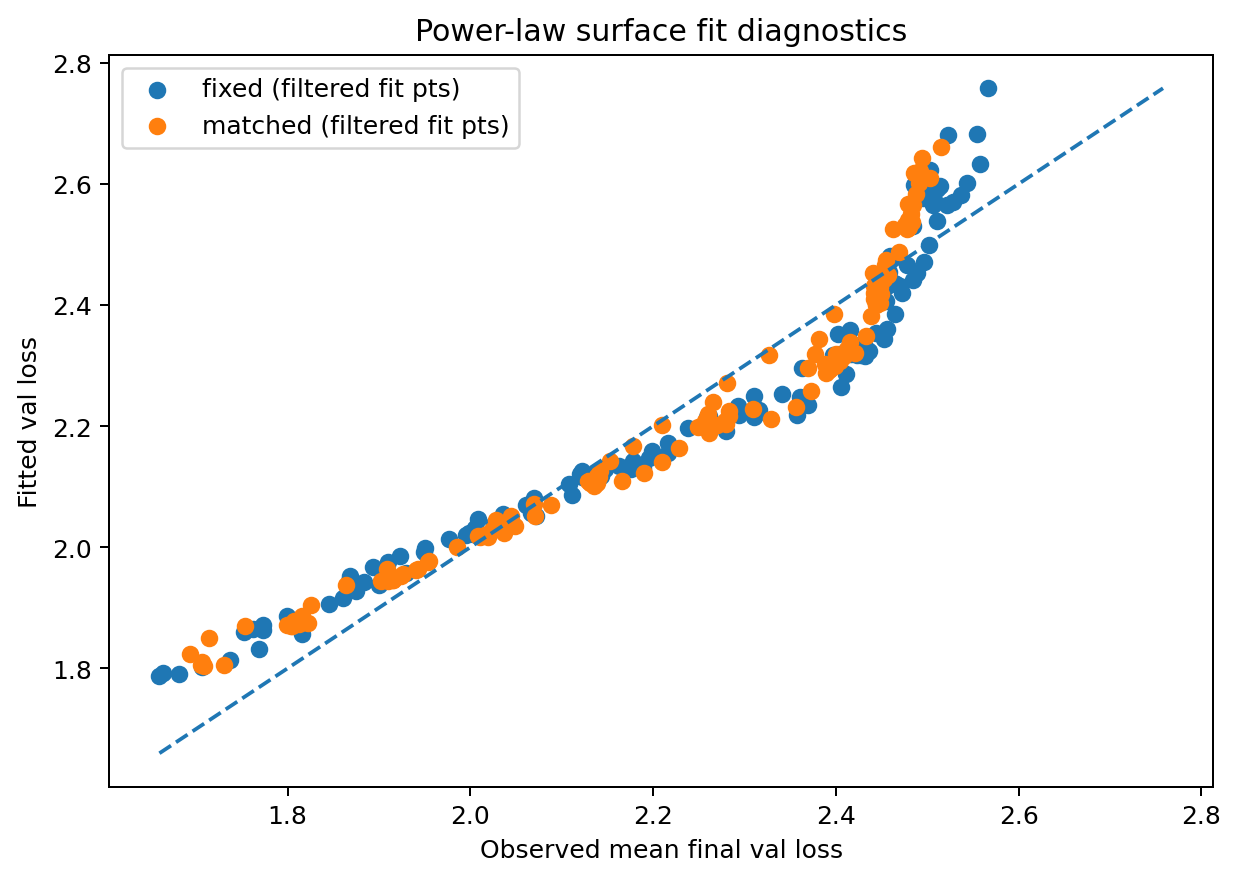

### frontier_loss_vs_budget.png

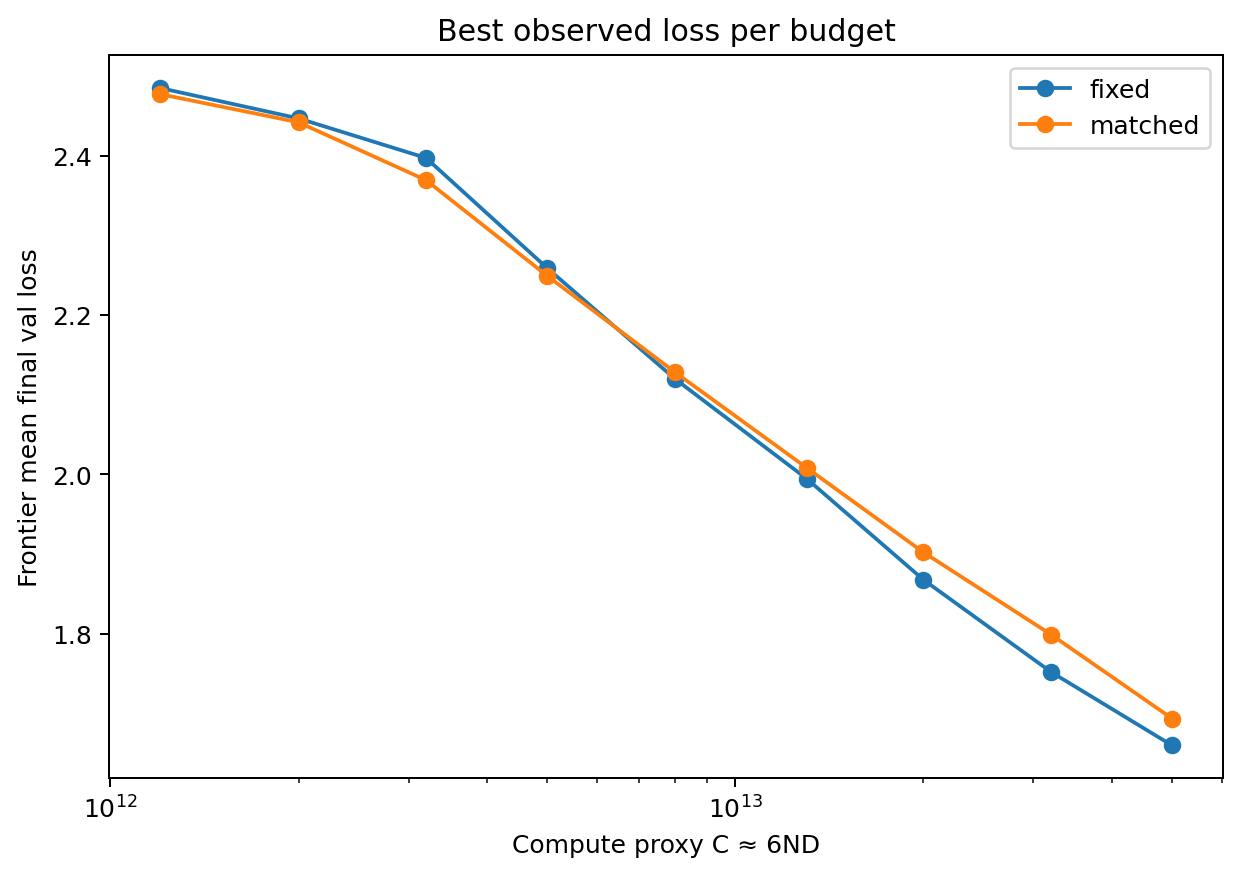

### frontier_num_params_vs_budget.png

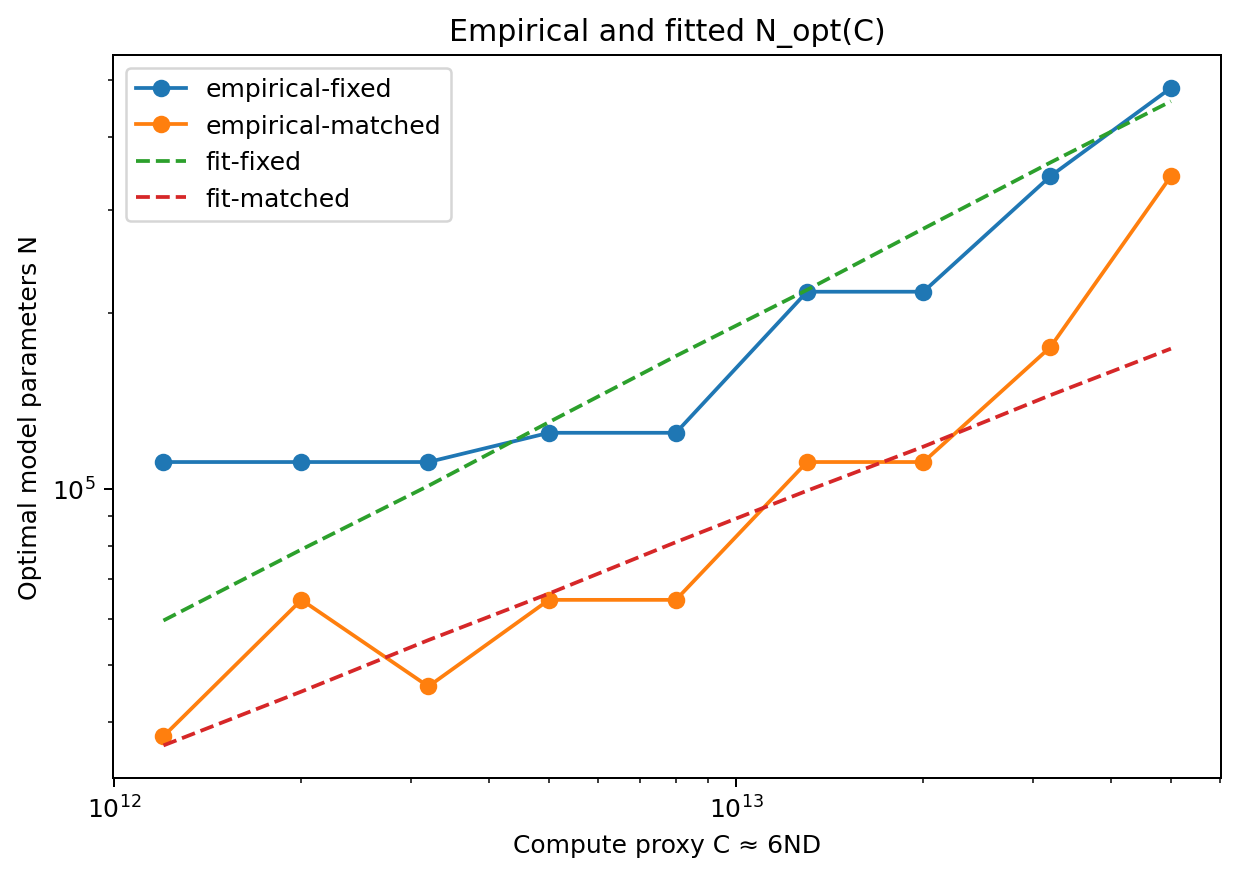

### frontier_token_param_ratio_vs_budget.png

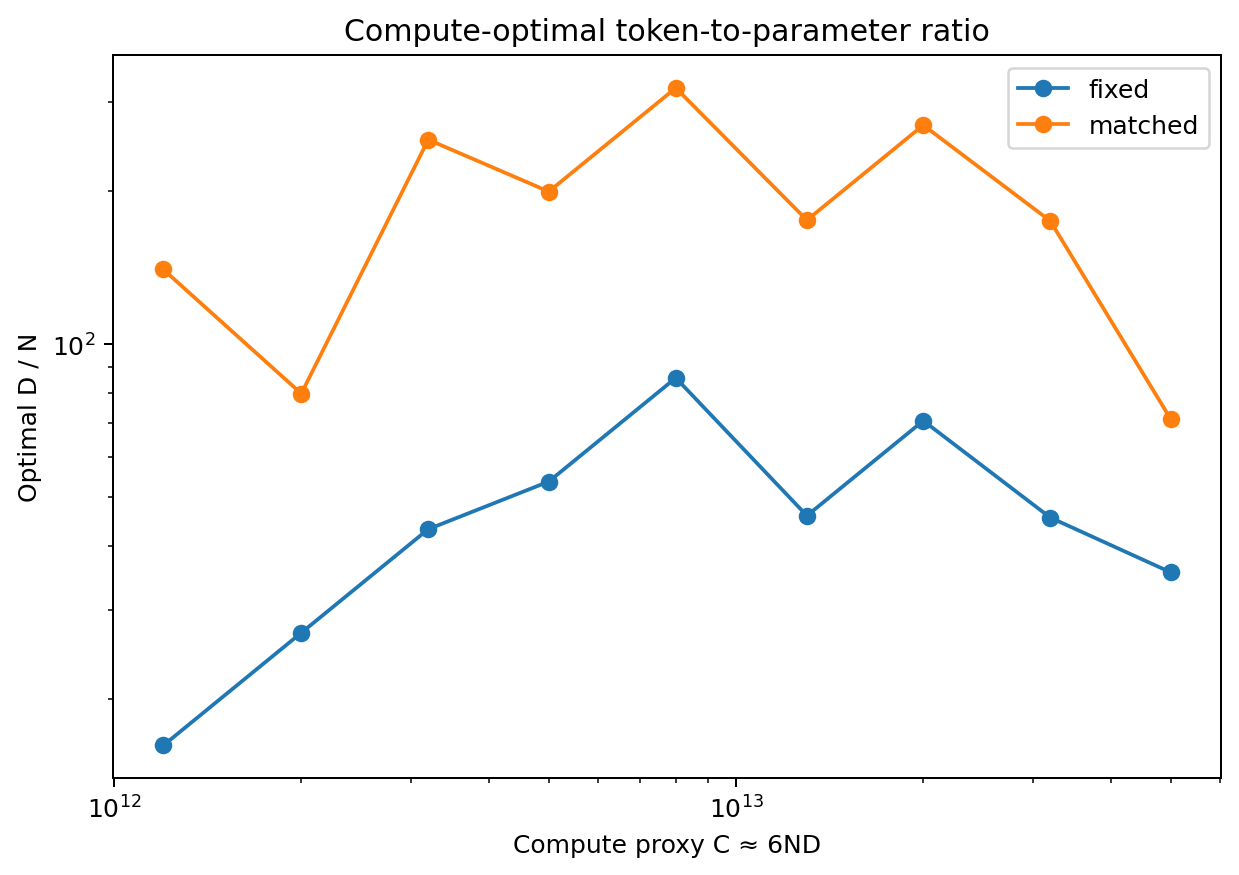

### frontier_tokens_vs_budget.png

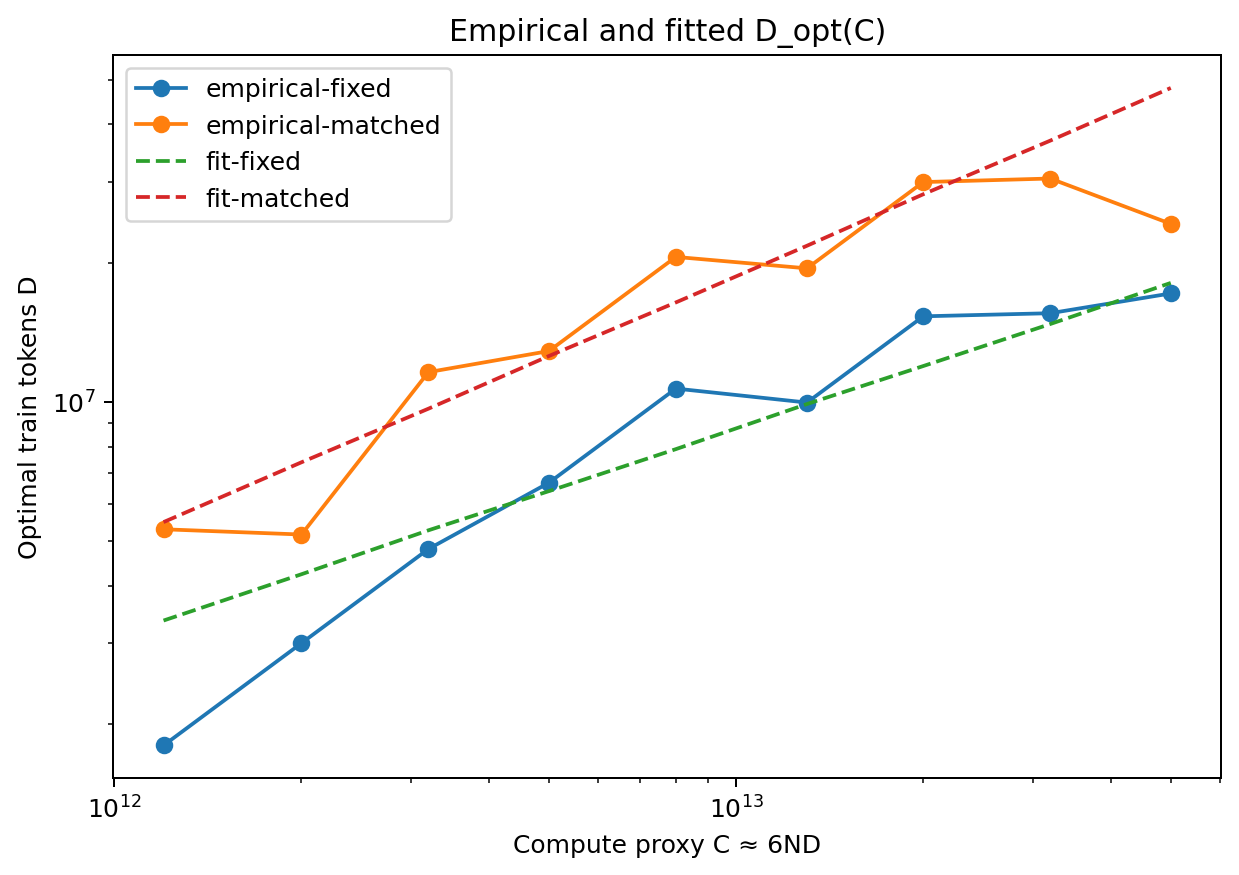

### iso_compute_budget_1e12_fixed.png

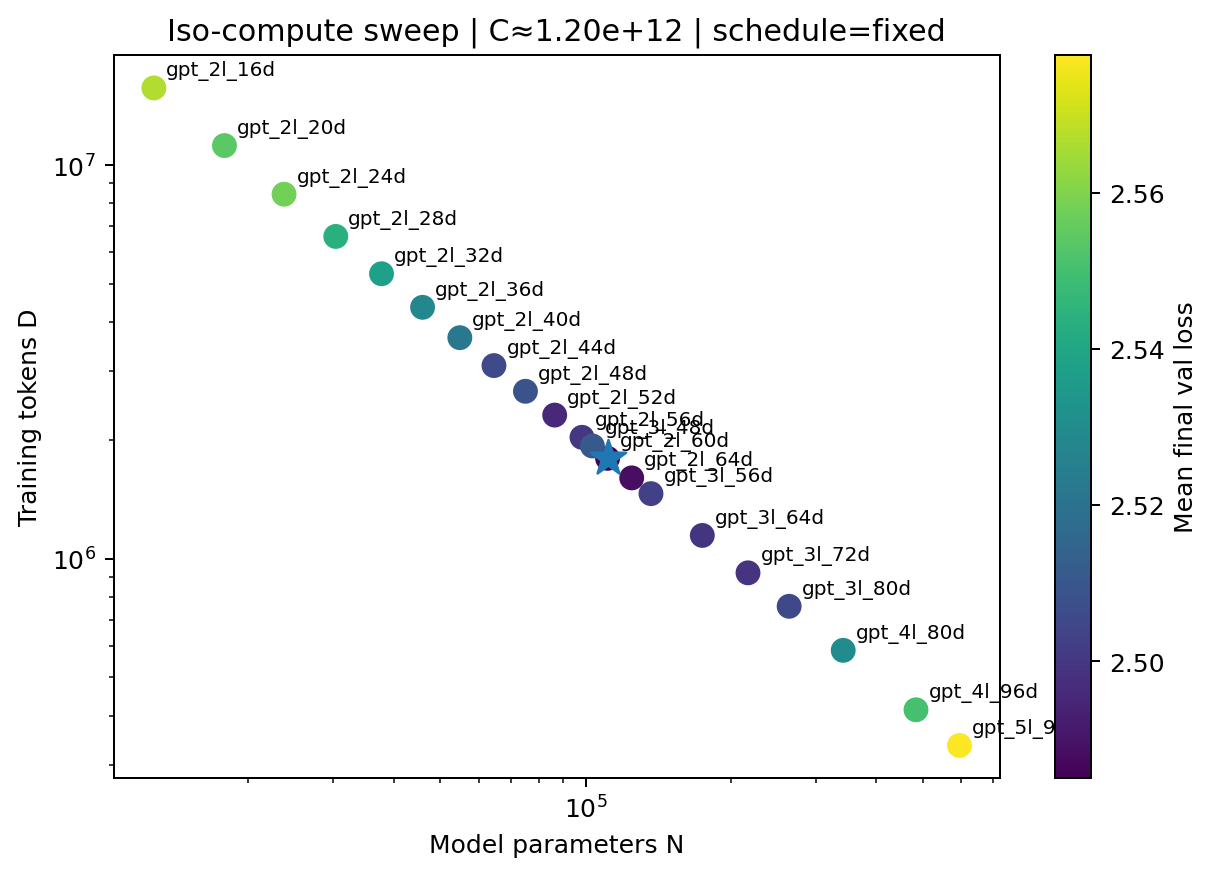

### iso_compute_budget_1e12_matched.png

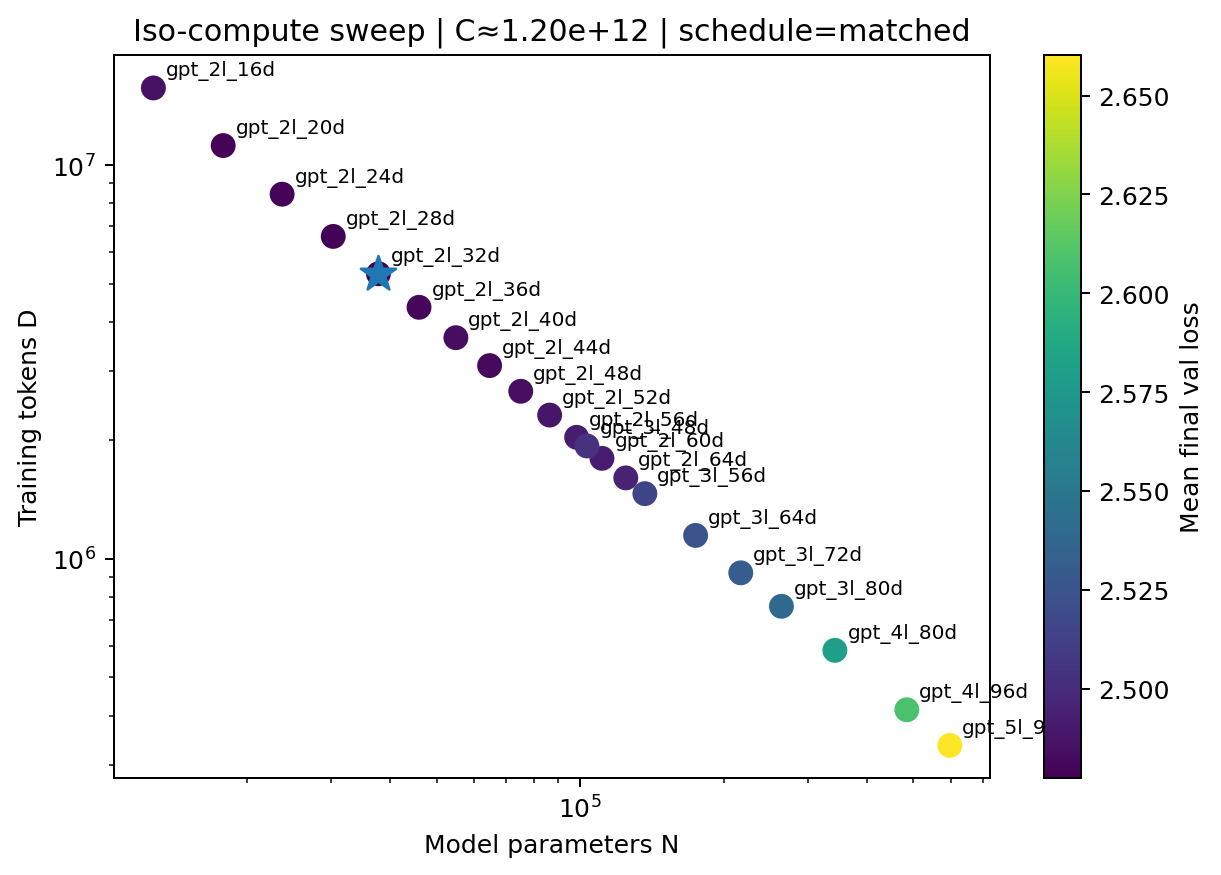

### iso_compute_budget_1e13_fixed.png

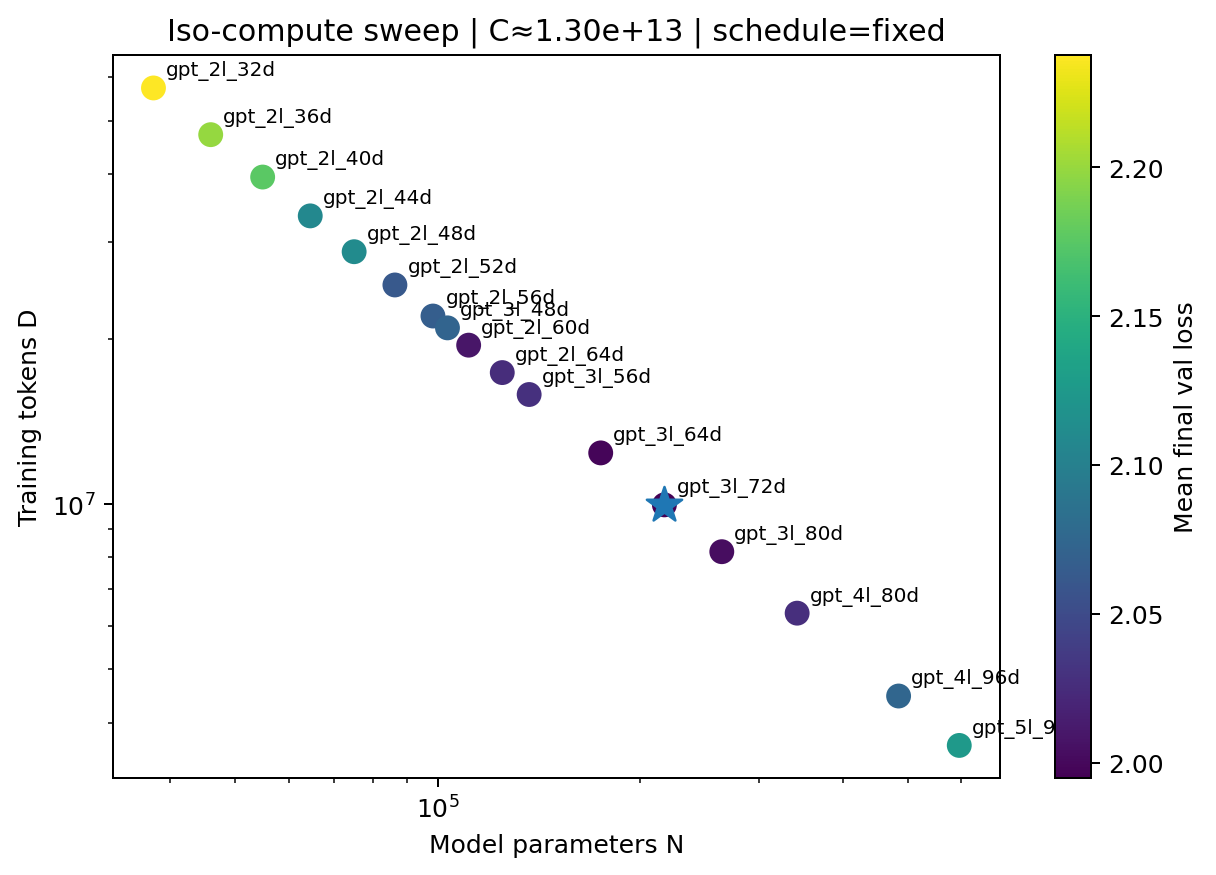

### iso_compute_budget_1e13_matched.png

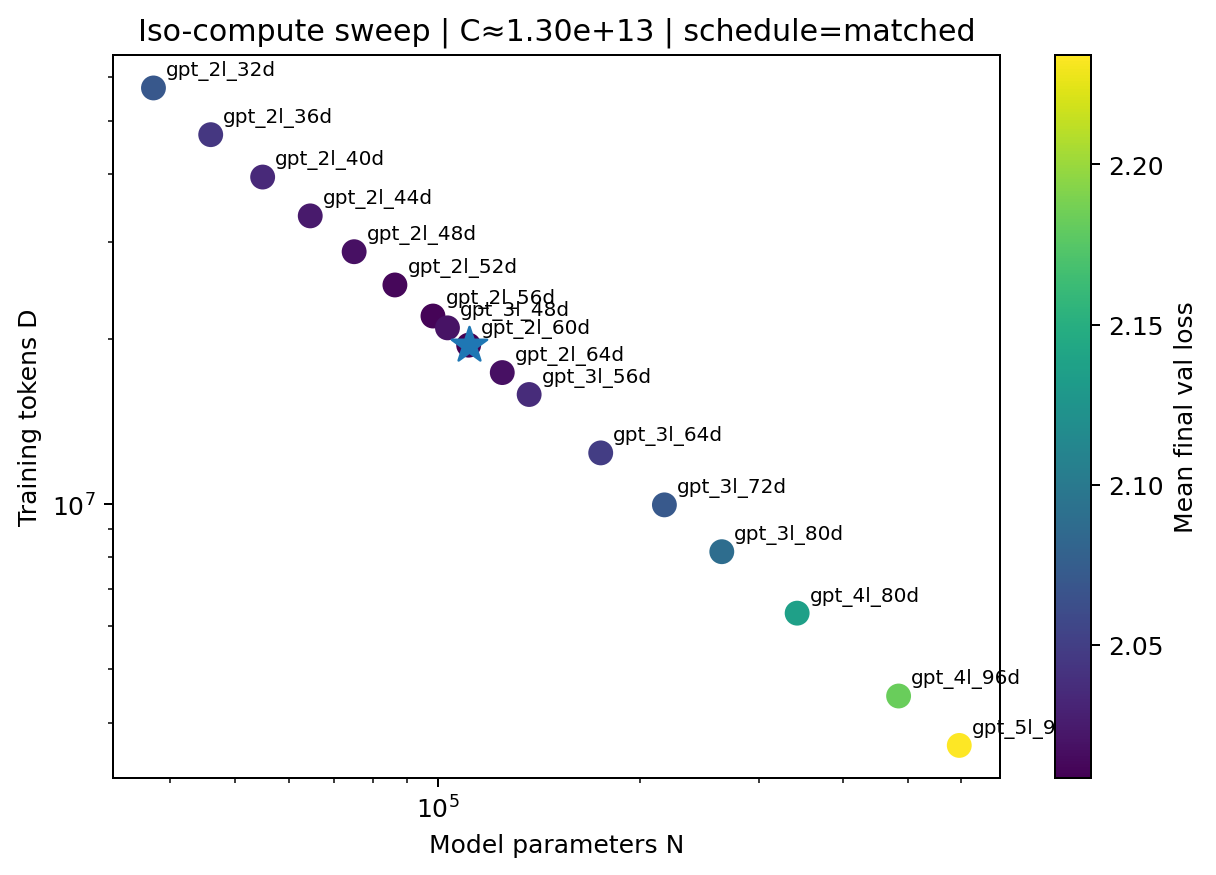

### iso_compute_budget_2e12_fixed.png

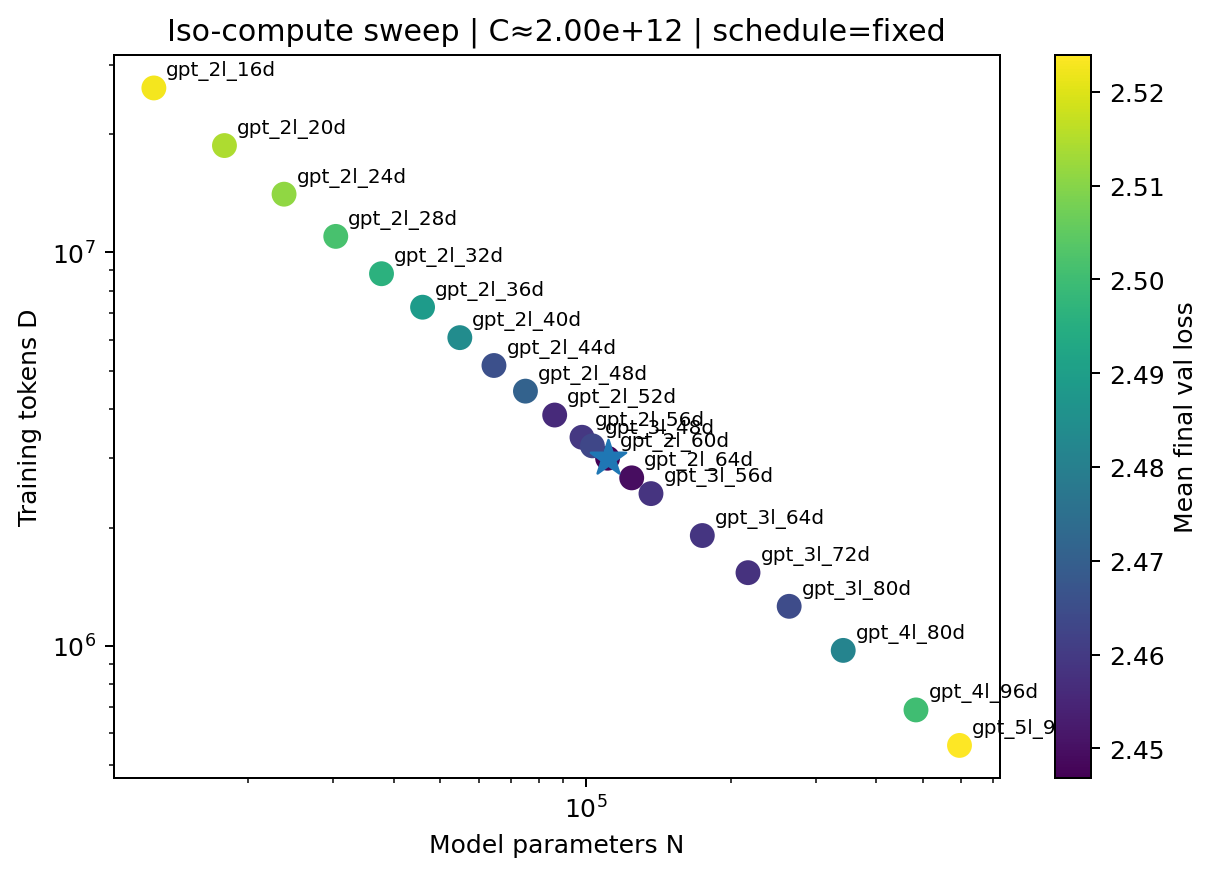

### iso_compute_budget_2e12_matched.png

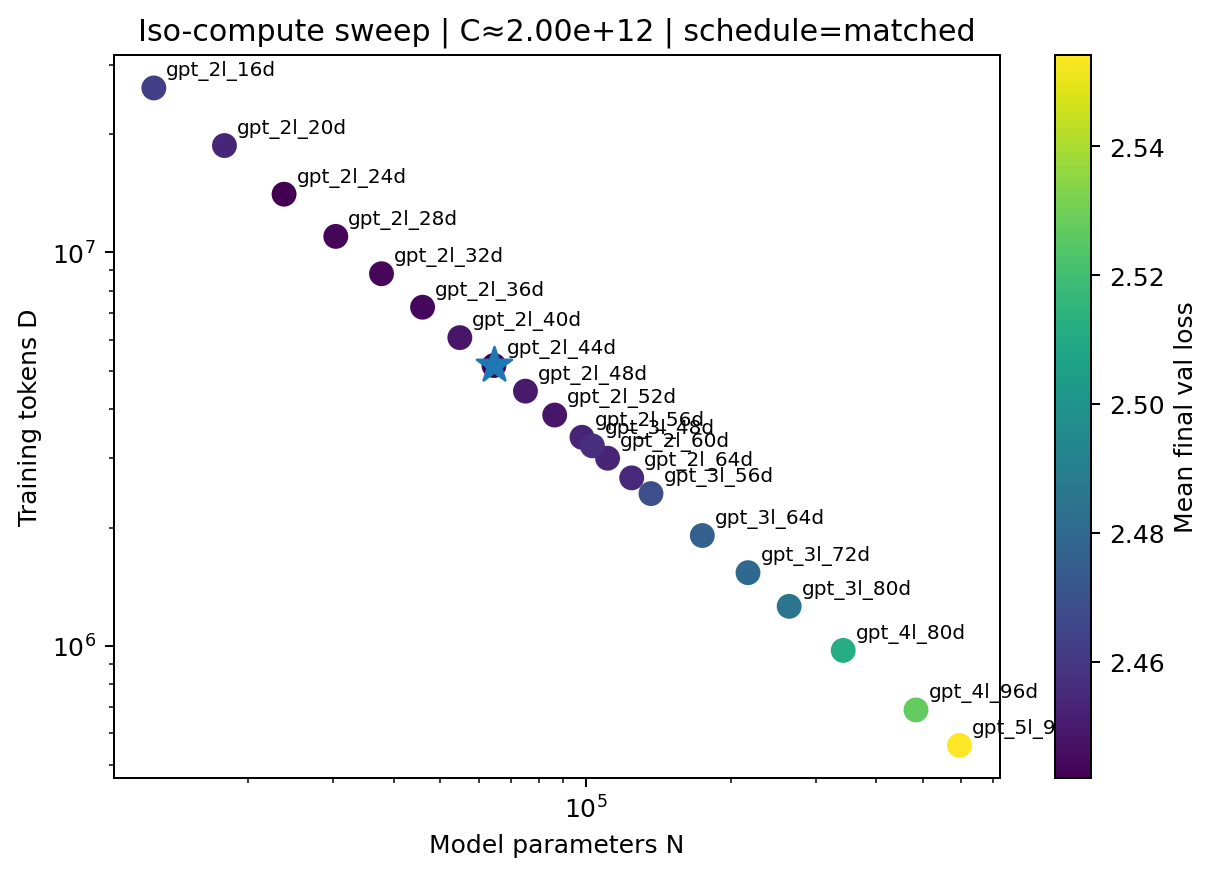

### iso_compute_budget_2e13_fixed.png

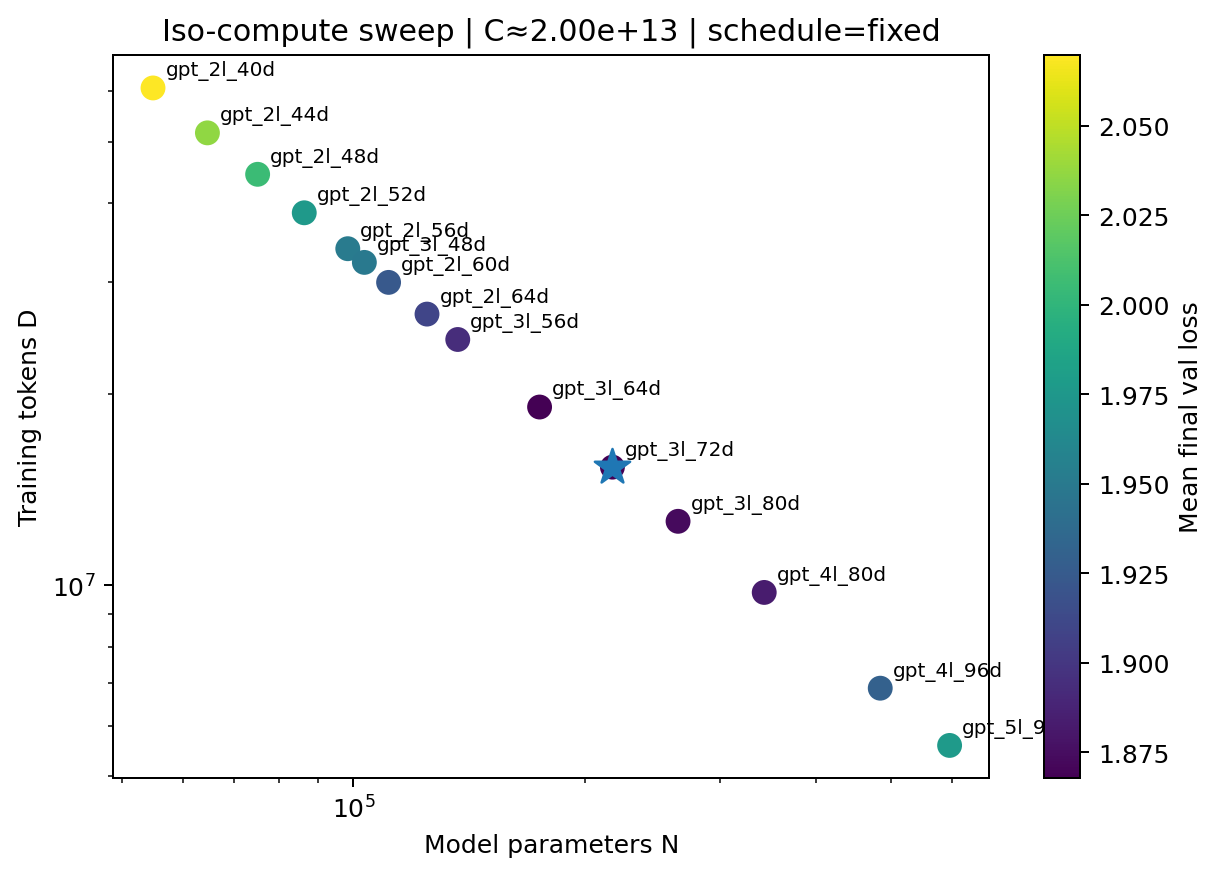

### iso_compute_budget_2e13_matched.png

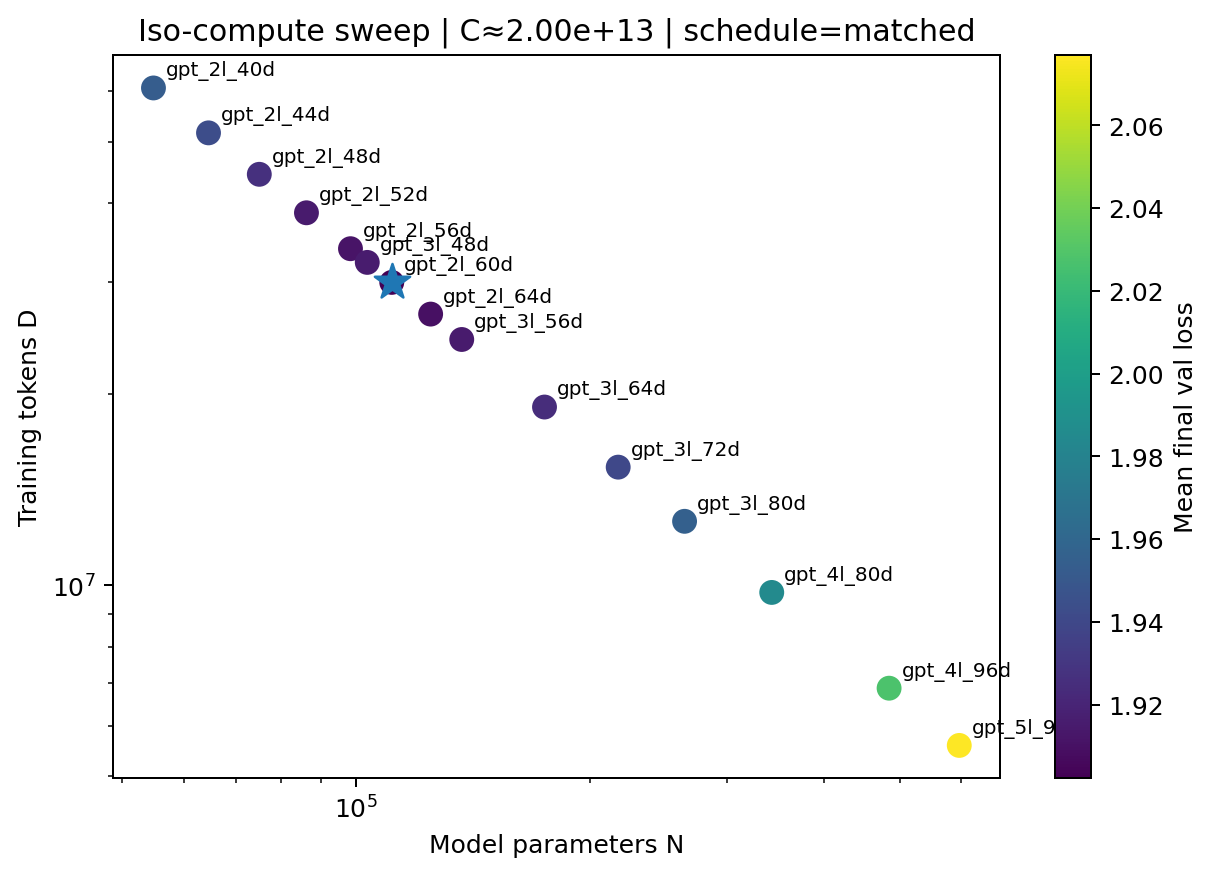

### iso_compute_budget_3e12_fixed.png

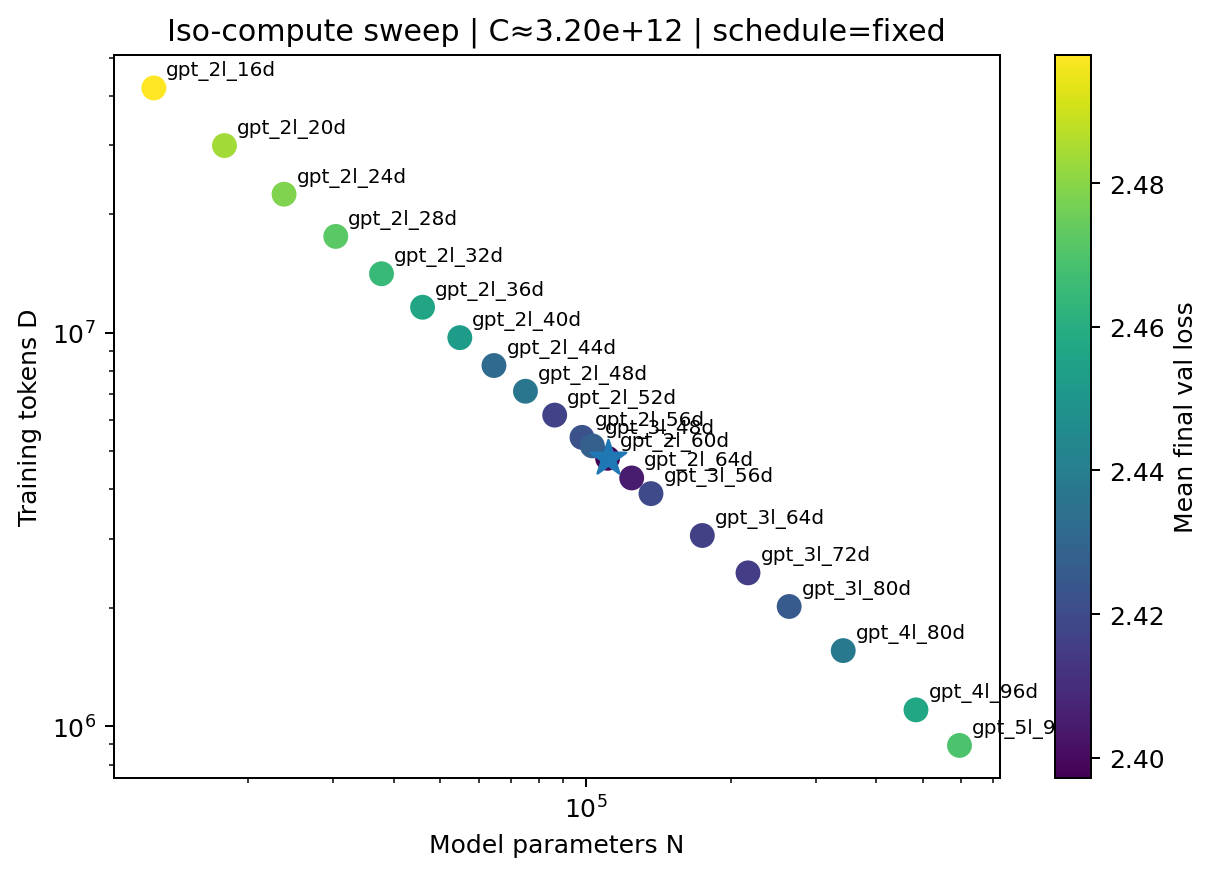

### iso_compute_budget_3e12_matched.png

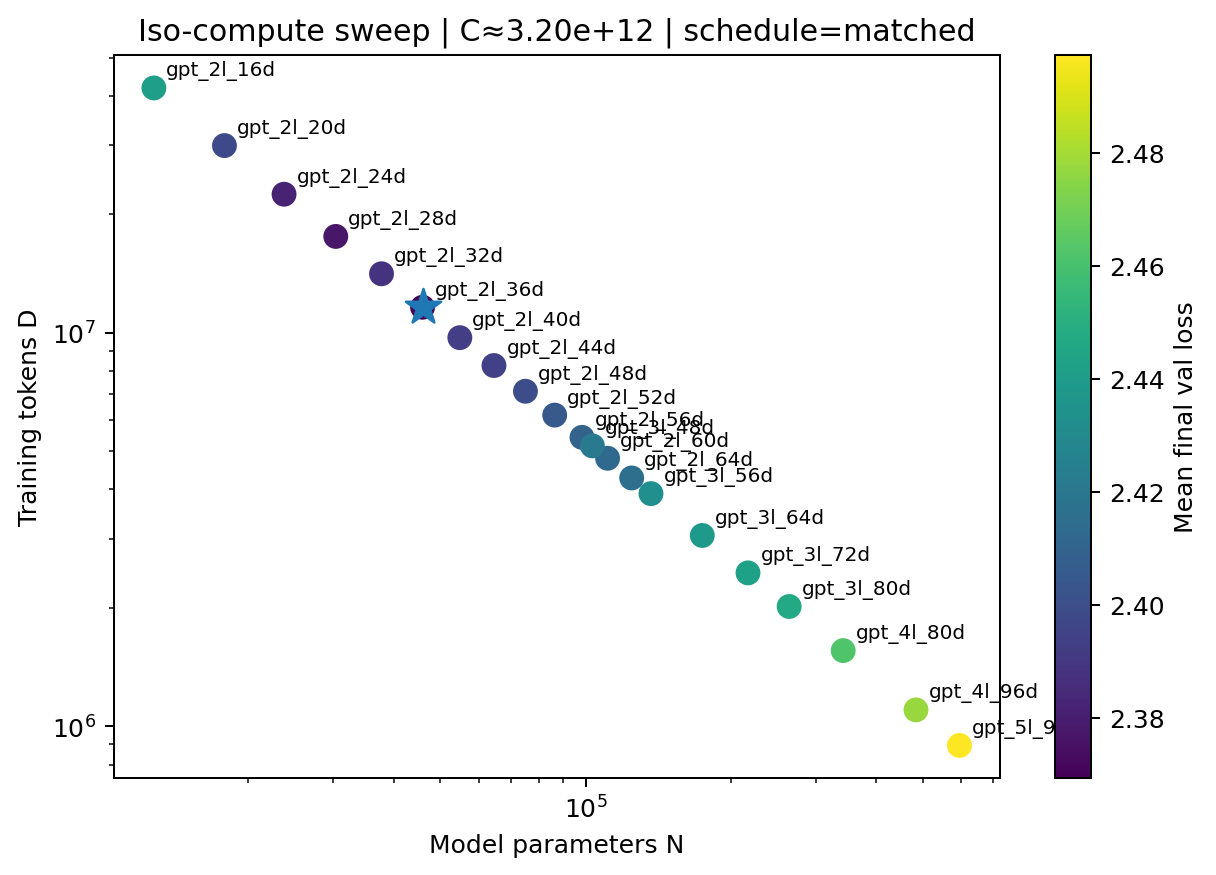

### iso_compute_budget_3e13_fixed.png

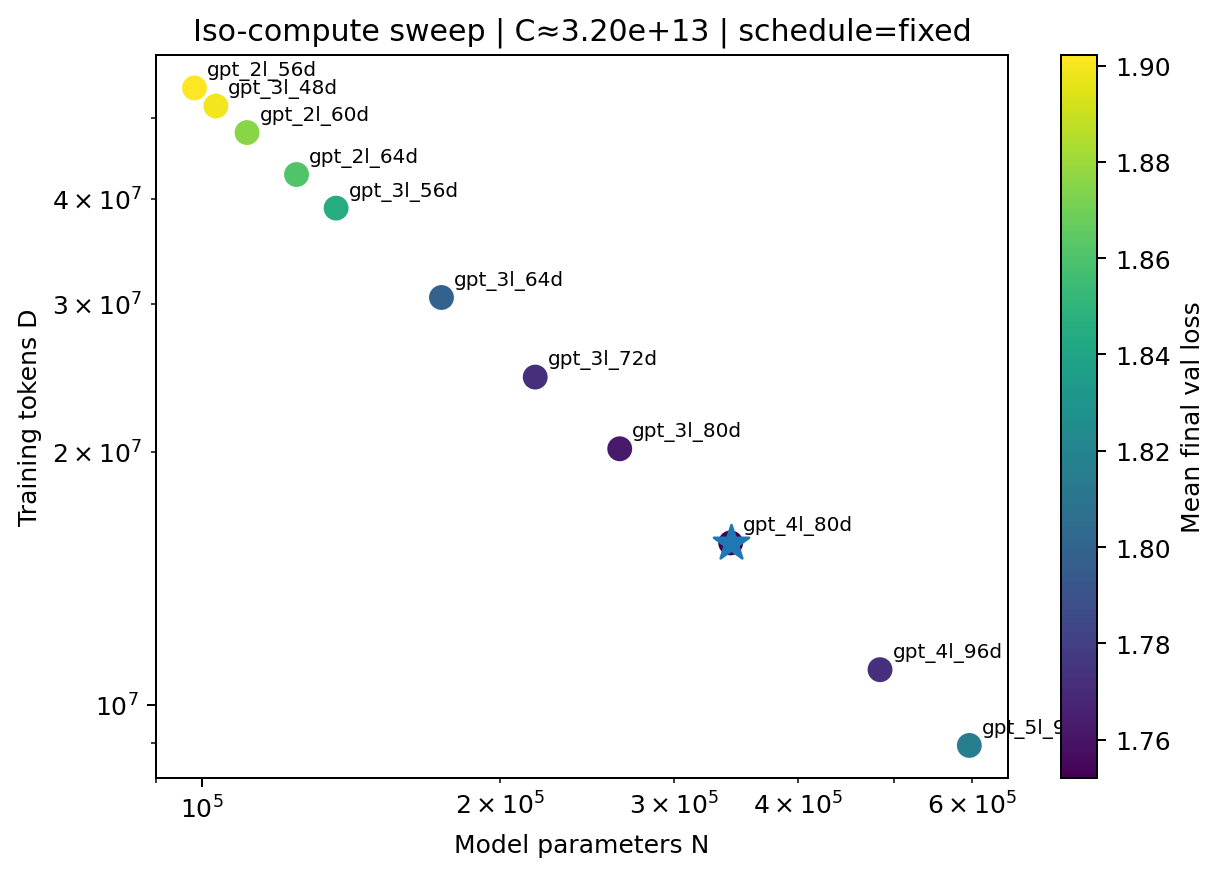

### iso_compute_budget_3e13_matched.png

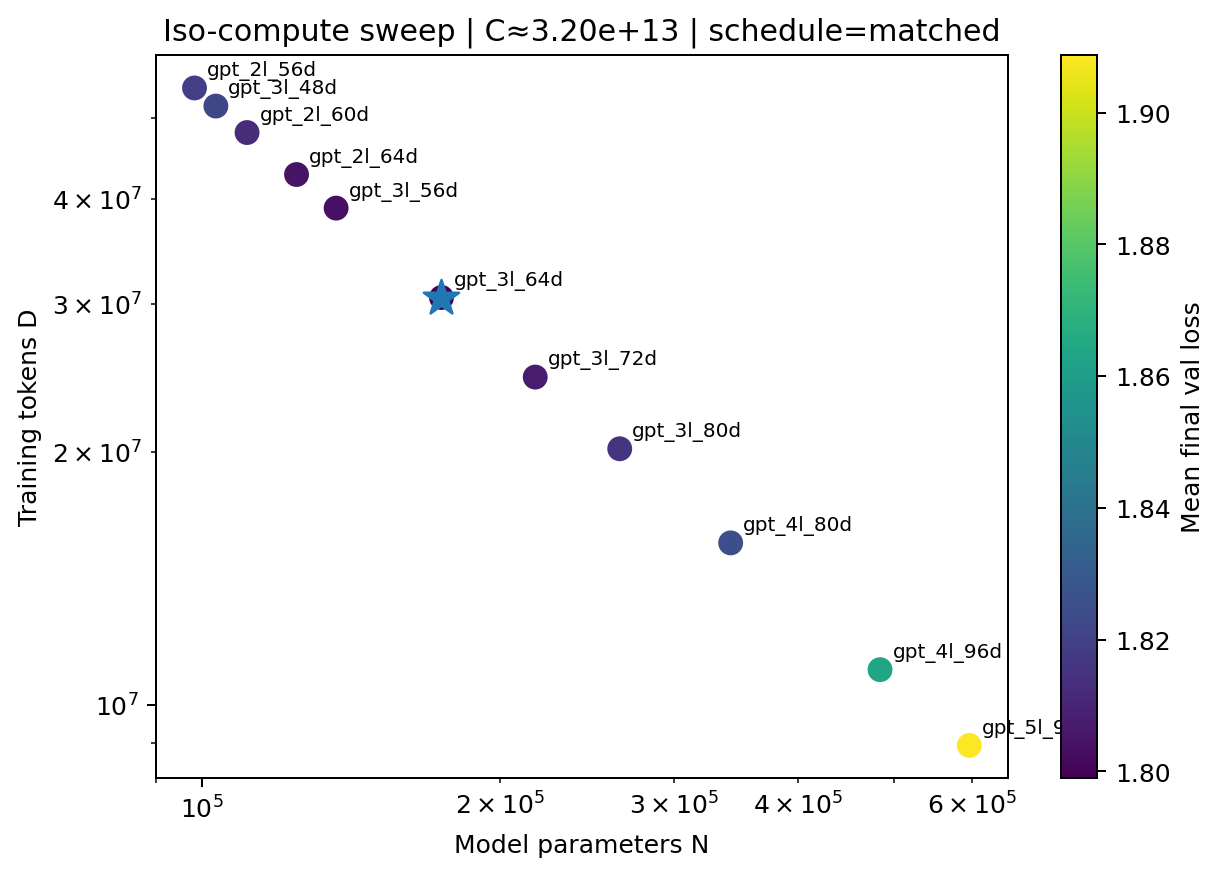

### iso_compute_budget_5e12_fixed.png

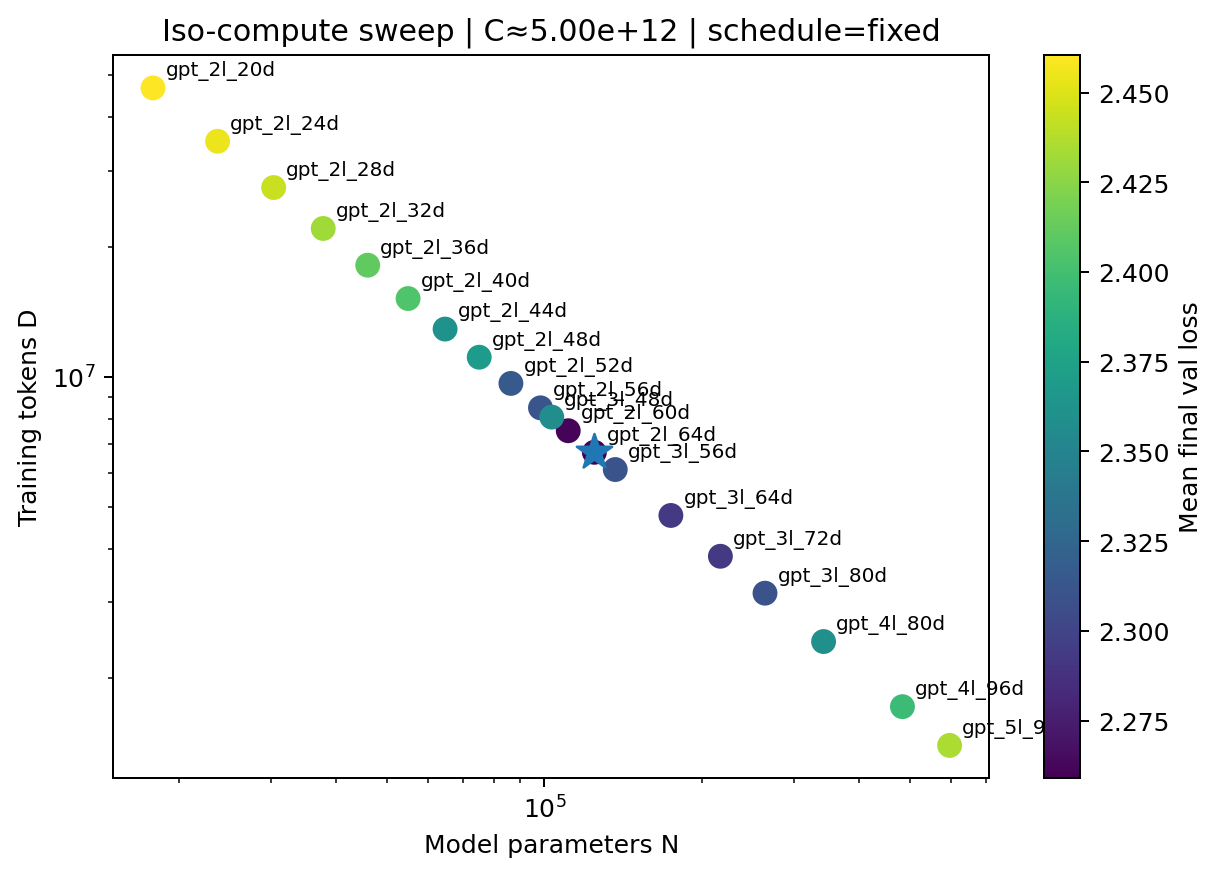

### iso_compute_budget_5e12_matched.png

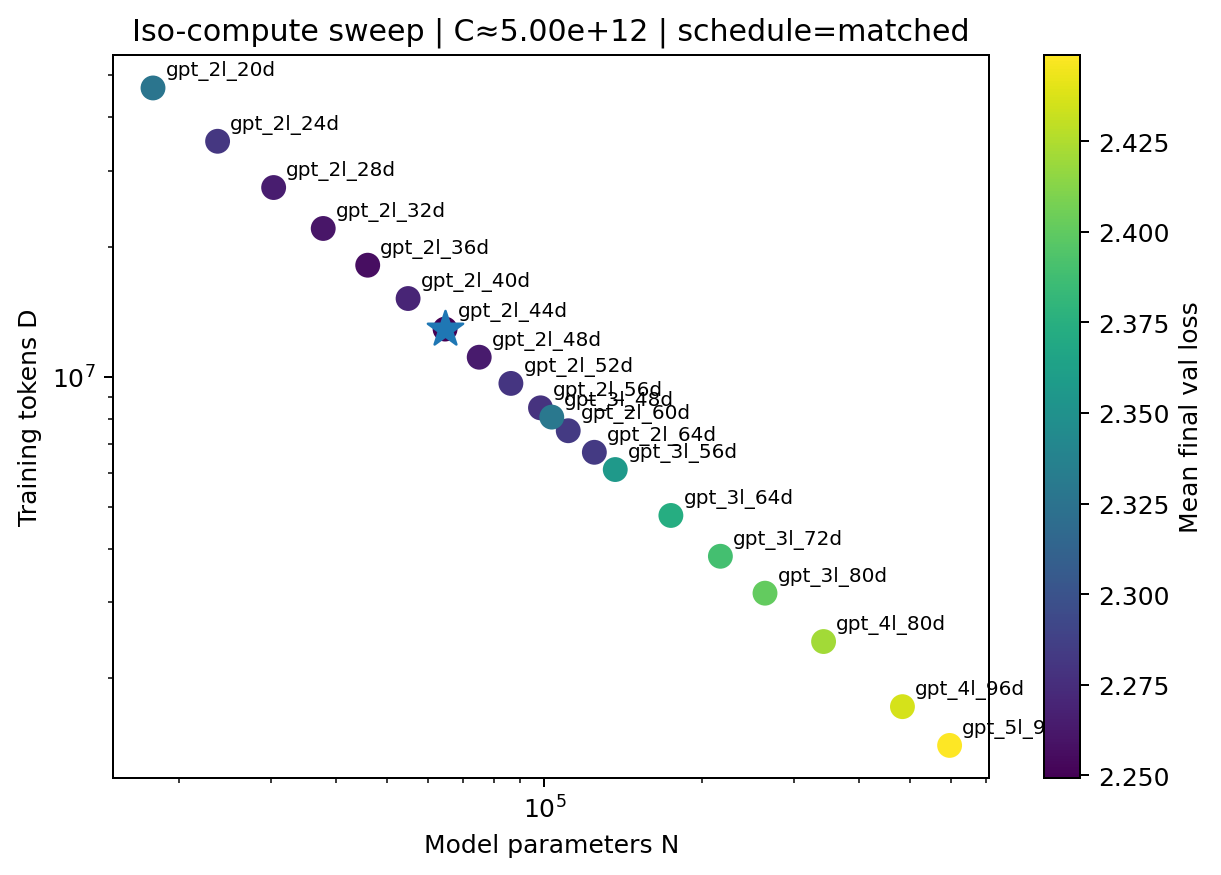

### iso_compute_budget_5e13_fixed.png

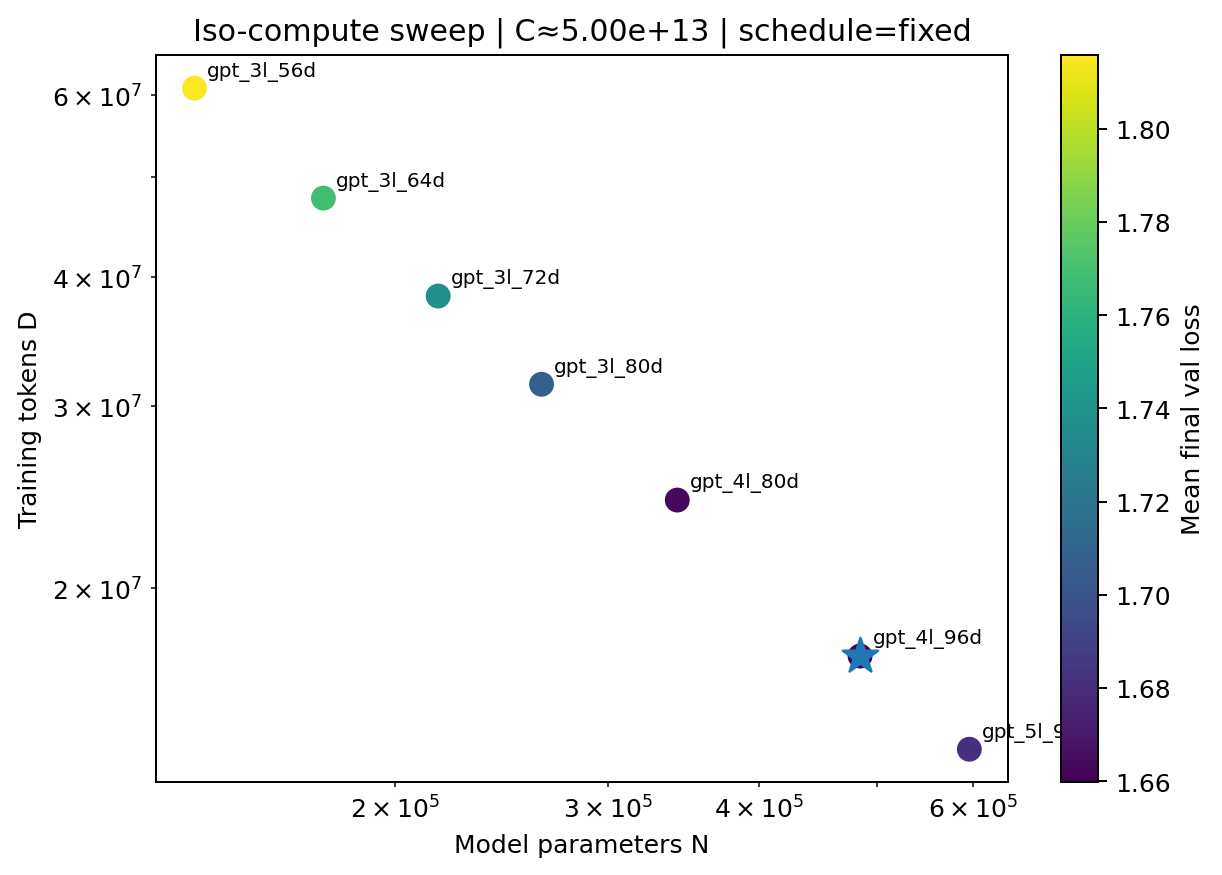

### iso_compute_budget_5e13_matched.png

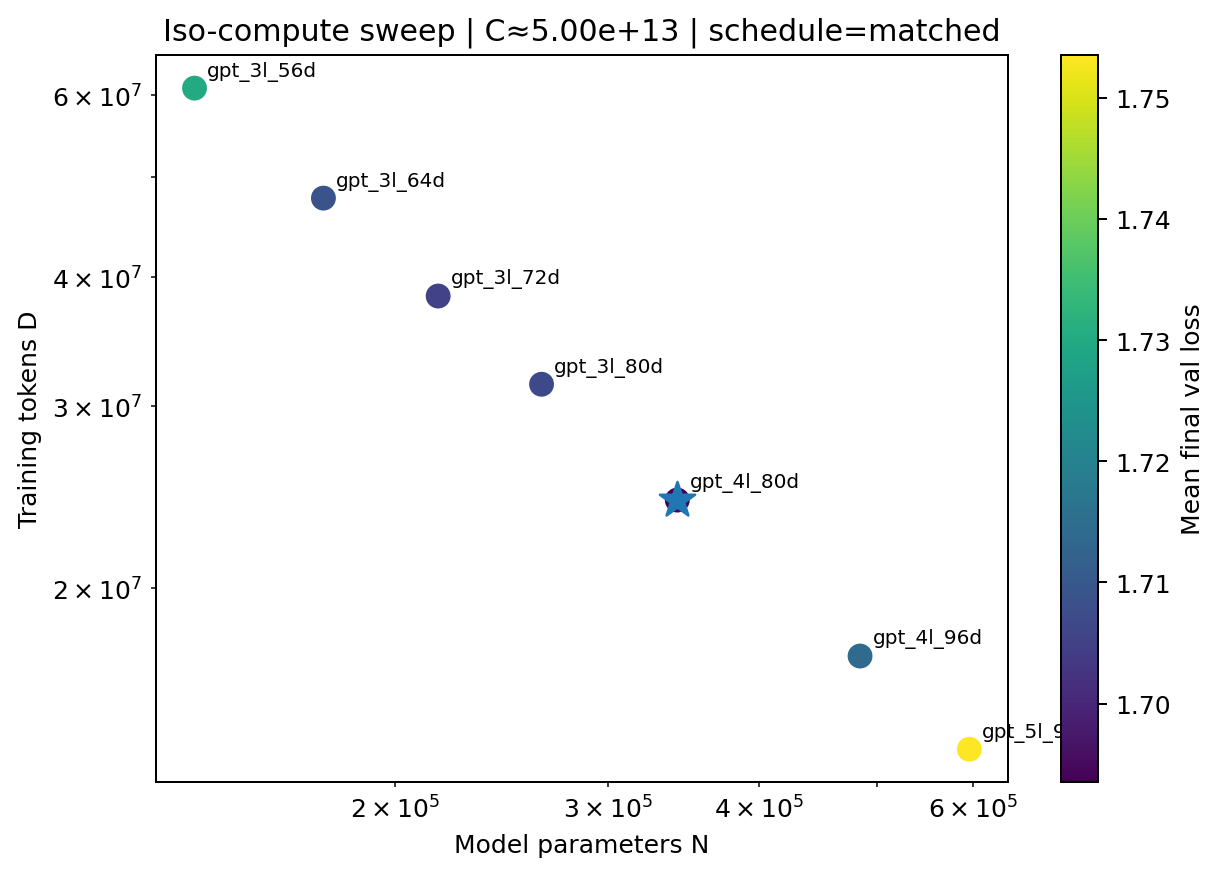

### iso_compute_budget_8e12_fixed.png

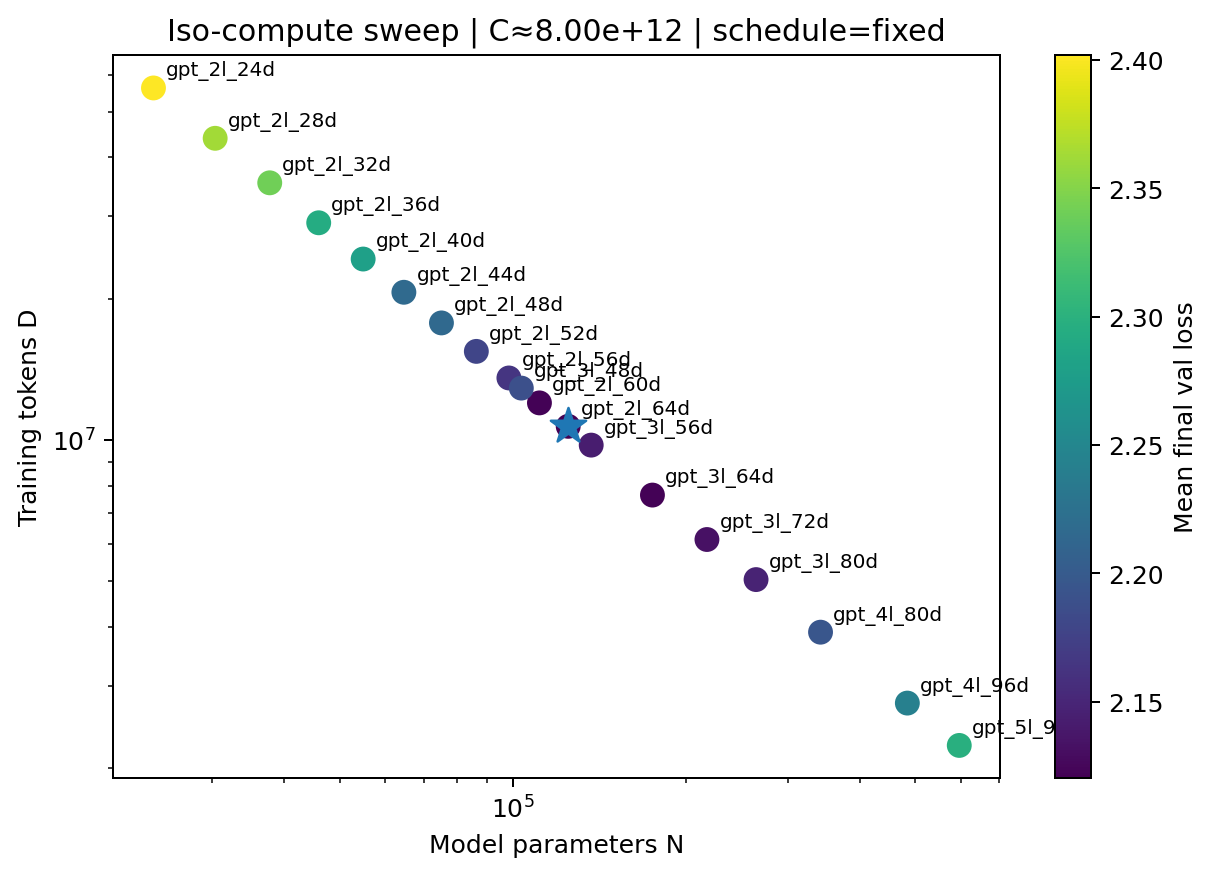

### iso_compute_budget_8e12_matched.png

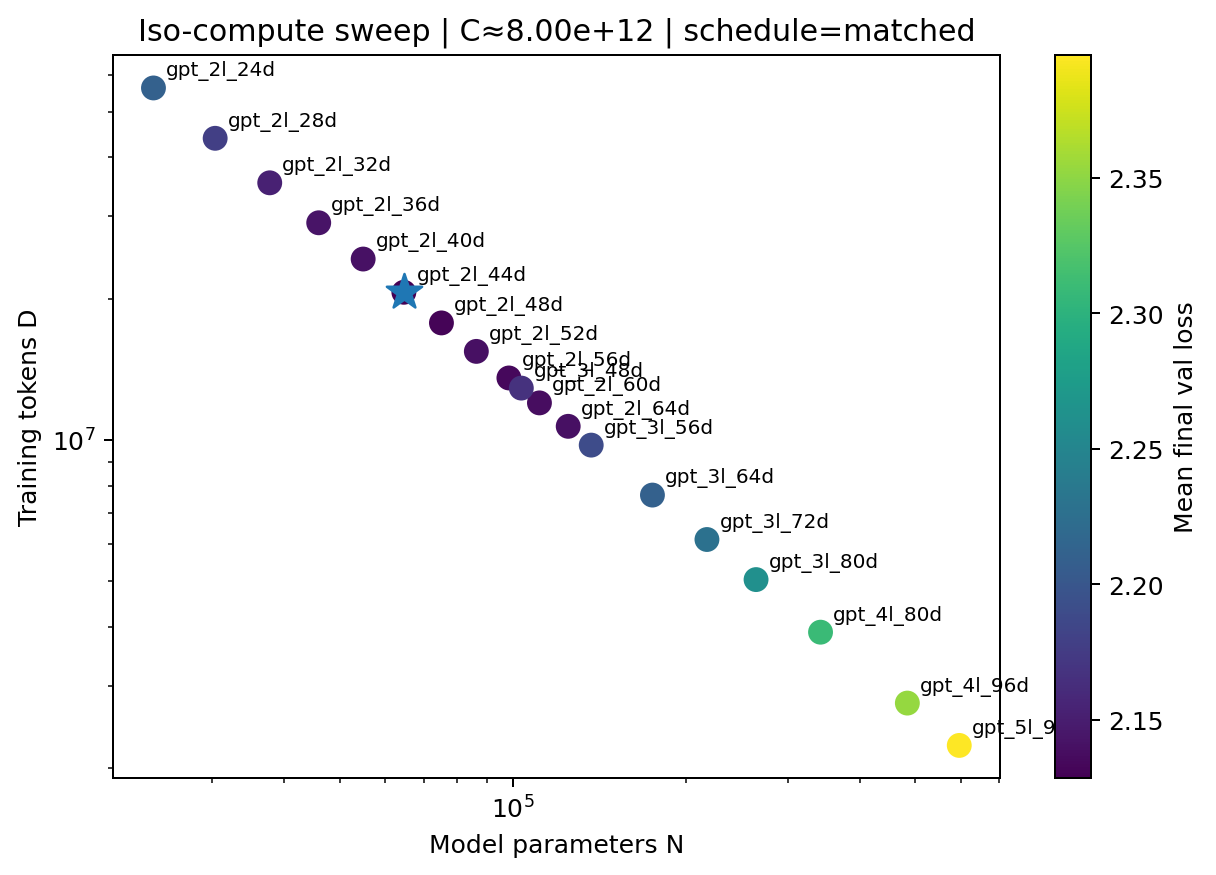

In [10]:
plot_dir = OUT_ROOT / "plots"
plot_paths = sorted(plot_dir.glob("*.png"))

for plot_path in plot_paths:
    display(Markdown(f"### {plot_path.name}"))
    display(Image(filename=str(plot_path)))


### Scaling Law Analysis

This section produces the core scaling-law plots and extracts the compute-optimal D/N ratios. The parametric scaling surface is:

$$L(N, D) = E + A \, N^{-\alpha} + B \, D^{-\beta}$$

and from it derive the optimal model size $N^*(C)$ and data size $D^*(C)$ at each compute budget $C \approx 6ND$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from compute_optimal.analysis import _surface_predict

plot_dir_scaling = ensure_dir(OUT_ROOT / "plots" / "scaling")

schedule_colors = {"matched": "#1f77b4", "fixed": "#ff7f0e"}
schedule_markers = {"matched": "o", "fixed": "s"}

if agg_df.empty:
    print("No aggregated results available.")
else:
    # Loss vs Compute (scaling trend)
    fig, ax = plt.subplots(figsize=(7, 5))
    for schedule, grp in frontier_df.groupby("schedule_regime"):
        g = grp.sort_values("budget_flops")
        ax.plot(g["budget_flops"], g["mean_final_val_loss"],
                marker=schedule_markers.get(schedule, "o"),
                color=schedule_colors.get(schedule, None),
                label=f"frontier ({schedule})")
    if not fitted_frontier_df.empty:
        for schedule, grp in fitted_frontier_df.groupby("schedule_regime"):
            g = grp.sort_values("budget_flops")
            ax.plot(g["budget_flops"], g["predicted_val_loss"],
                    linestyle="--", color=schedule_colors.get(schedule, None),
                    label=f"fit ({schedule})")
    ax.set_xscale("log")
    ax.set_xlabel("Compute budget C (FLOPs)")
    ax.set_ylabel("Best validation loss L*(C)")
    ax.set_title("Scaling of optimal loss with compute")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(plot_dir_scaling / "loss_vs_compute.png", dpi=180, bbox_inches="tight")
    plt.show()

    # Iso-compute Loss vs N
    budgets_sorted = sorted(agg_df["budget_flops"].unique())
    n_budget_cols = min(3, len(budgets_sorted))
    n_budget_rows = int(np.ceil(len(budgets_sorted) / n_budget_cols))
    fig, axes = plt.subplots(n_budget_rows, n_budget_cols,
                             figsize=(4.5 * n_budget_cols, 3.5 * n_budget_rows),
                             squeeze=False, sharey=True)
    for idx, budget in enumerate(budgets_sorted):
        row_idx, col_idx = divmod(idx, n_budget_cols)
        ax = axes[row_idx][col_idx]
        for schedule, grp in agg_df.groupby("schedule_regime"):
            sub = grp[grp["budget_flops"] == budget].sort_values("num_params")
            ax.plot(sub["num_params"], sub["mean_final_val_loss"],
                    marker=schedule_markers.get(schedule, "o"),
                    color=schedule_colors.get(schedule, None),
                    label=schedule, markersize=5)
        if not surface_df.empty:
            surf_row = surface_df[surface_df["schedule_regime"] == "matched"]
            if not surf_row.empty and surf_row.iloc[0]["status"] == "ok":
                p = surf_row.iloc[0]
                params_dict = {"E": float(p["E"]), "A": float(p["A"]),
                               "alpha": float(p["alpha"]), "B": float(p["B"]),
                               "beta": float(p["beta"])}
                n_range = np.logspace(np.log10(agg_df["num_params"].min()),
                                      np.log10(agg_df["num_params"].max()), 200)
                d_for_budget = budget / (6.0 * n_range)
                pred_loss = _surface_predict(n_range, d_for_budget, params_dict)
                ax.plot(n_range, pred_loss, "k--", alpha=0.5, linewidth=1, label="surface fit")
        ax.set_xscale("log")
        ax.set_title(f"C = {budget:.1e}", fontsize=9)
        if col_idx == 0:
            ax.set_ylabel("Val loss")
        if row_idx == n_budget_rows - 1:
            ax.set_xlabel("N (params)")
        ax.legend(fontsize=7)
    for idx in range(len(budgets_sorted), n_budget_rows * n_budget_cols):
        row_idx, col_idx = divmod(idx, n_budget_cols)
        axes[row_idx][col_idx].set_visible(False)
    fig.suptitle("Iso-compute: validation loss vs model size", fontsize=11, y=1.01)
    fig.tight_layout()
    fig.savefig(plot_dir_scaling / "iso_compute_loss_vs_N.png", dpi=180, bbox_inches="tight")
    plt.show()

    # Fitted surface predicted loss landscape
    if not surface_df.empty:
        for _, surf_row in surface_df.iterrows():
            if surf_row["status"] != "ok":
                continue
            schedule = surf_row["schedule_regime"]
            params_dict = {"E": float(surf_row["E"]), "A": float(surf_row["A"]),
                           "alpha": float(surf_row["alpha"]), "B": float(surf_row["B"]),
                           "beta": float(surf_row["beta"])}
            n_grid = np.logspace(np.log10(agg_df["num_params"].min() * 0.8),
                                 np.log10(agg_df["num_params"].max() * 1.2), 80)
            d_grid = np.logspace(np.log10(agg_df["actual_train_tokens"].min() * 0.8),
                                 np.log10(agg_df["actual_train_tokens"].max() * 1.2), 80)
            N, D = np.meshgrid(n_grid, d_grid)
            L = _surface_predict(N, D, params_dict)

            fig, ax = plt.subplots(figsize=(7, 5.5))
            cs = ax.contourf(N, D, L, levels=30, cmap="viridis_r")
            fig.colorbar(cs, ax=ax, label="Predicted val loss")
            sub = agg_df[agg_df["schedule_regime"] == schedule]
            ax.scatter(sub["num_params"], sub["actual_train_tokens"],
                       c=sub["mean_final_val_loss"], cmap="viridis_r",
                       edgecolors="white", linewidths=0.5, s=40, zorder=5)
            for budget in budgets_sorted:
                iso_n = np.logspace(np.log10(n_grid.min()), np.log10(n_grid.max()), 300)
                iso_d = budget / (6.0 * iso_n)
                mask = (iso_d >= d_grid.min()) & (iso_d <= d_grid.max())
                ax.plot(iso_n[mask], iso_d[mask], "w--", alpha=0.6, linewidth=0.8)
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlabel("Model parameters N")
            ax.set_ylabel("Training tokens D")
            ax.set_title(
                f"Fitted scaling surface (schedule={schedule})\n"
                f"L(N,D) = {surf_row['E']:.4f} + {surf_row['A']:.4f} N^{{-{surf_row['alpha']:.3f}}} "
                f"+ {surf_row['B']:.4f} D^{{-{surf_row['beta']:.3f}}}"
            )
            fig.tight_layout()
            fig.savefig(plot_dir_scaling / f"scaling_surface_{schedule}.png", dpi=180, bbox_inches="tight")
            plt.show()

    # Loss vs D/N ratio (over/under-training diagnosis)
    fig, ax = plt.subplots(figsize=(7, 5))
    for schedule, grp in agg_df.groupby("schedule_regime"):
        ax.scatter(grp["actual_d_over_n"], grp["mean_final_val_loss"],
                   c=schedule_colors.get(schedule, None),
                   marker=schedule_markers.get(schedule, "o"),
                   label=schedule, alpha=0.7, s=40)
    ax.set_xscale("log")
    ax.set_xlabel("D / N  (tokens per parameter)")
    ax.set_ylabel("Mean final val loss")
    ax.set_title("Val loss vs token-to-parameter ratio")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir_scaling / "loss_vs_d_over_n.png", dpi=180, bbox_inches="tight")
    plt.show()

print(f"Scaling plots saved to: {plot_dir_scaling}")


Scaling plots saved to: /home/jovyan/persisted_storage/JHU Courses/RESEARCH PROJECTS/Advanced Applied ML/outputs/main_v2/plots/scaling


### Compute-Optimal D/N Ratio

For each compute budget, the empirical frontier gives the model that achieved the lowest loss. The ratio $D^*/N^*$ at that frontier point tells us how many tokens per parameter are optimal.

The fitted surface also predicts $D^*(C)/N^*(C)$ analytically.
Chinchilla found $D^*/N^* \approx 20$; im compare against that.

In [ ]:

if frontier_df.empty:
    print("No frontier data available.")
else:
    print("=" * 90)
    print("EMPIRICAL D/N RATIOS (from iso-compute sweep frontier)")
    print("=" * 90)
    emp_cols = ["budget_flops", "schedule_regime", "model_name", "num_params",
                "actual_train_tokens", "frontier_token_parameter_ratio", "mean_final_val_loss"]
    display(frontier_df[[c for c in emp_cols if c in frontier_df.columns]].sort_values(
        ["schedule_regime", "budget_flops"]))

if not fitted_frontier_df.empty:
    print("=" * 90)
    print("FITTED D/N RATIOS (from power-law surface optimisation)")
    print("=" * 90)
    fit_cols = ["budget_flops", "schedule_regime", "predicted_num_params",
                "predicted_train_tokens", "predicted_val_loss",
                "predicted_token_parameter_ratio",
                "within_n_support", "within_d_support"]
    display(fitted_frontier_df[[c for c in fit_cols if c in fitted_frontier_df.columns]].sort_values(
        ["schedule_regime", "budget_flops"]))

# Summary comparison with Chinchilla
if not frontier_df.empty:
    print("\n" + "=" * 90)
    print("D/N RATIO SUMMARY vs CHINCHILLA (D*/N* ~ 20)")
    print("=" * 90)
    for schedule, grp in frontier_df.groupby("schedule_regime"):
        ratios = grp.sort_values("budget_flops")["frontier_token_parameter_ratio"].values
        budgets = grp.sort_values("budget_flops")["budget_flops"].values
        mean_ratio = np.mean(ratios)
        print(f"\nSchedule: {schedule}")
        for b, r in zip(budgets, ratios):
            print(f"  C={b:.1e}  ->  D*/N* = {r:.1f}")
        print(f"  Mean D*/N* across budgets: {mean_ratio:.1f}")
        print(f"  Chinchilla ratio = 20; deviation = {mean_ratio - 20:+.1f}")

if not fitted_frontier_df.empty:
    print("\n" + "-" * 60)
    for schedule, grp in fitted_frontier_df.groupby("schedule_regime"):
        fit_ratios = grp.sort_values("budget_flops")["predicted_token_parameter_ratio"].values
        fit_budgets = grp.sort_values("budget_flops")["budget_flops"].values
        fit_mean = np.mean(fit_ratios)
        print(f"\nFitted surface ({schedule}):")
        for b, r in zip(fit_budgets, fit_ratios):
            print(f"  C={b:.1e}  ->  D*/N* = {r:.1f}")
        print(f"  Mean fitted D*/N*: {fit_mean:.1f}")

# Plot D/N vs C
fig, ax = plt.subplots(figsize=(7, 5))
if not frontier_df.empty:
    for schedule, grp in frontier_df.groupby("schedule_regime"):
        g = grp.sort_values("budget_flops")
        ax.plot(g["budget_flops"], g["frontier_token_parameter_ratio"],
                marker=schedule_markers.get(schedule, "o"),
                color=schedule_colors.get(schedule, None),
                label=f"empirical ({schedule})")
if not fitted_frontier_df.empty:
    for schedule, grp in fitted_frontier_df.groupby("schedule_regime"):
        g = grp.sort_values("budget_flops")
        ax.plot(g["budget_flops"], g["predicted_token_parameter_ratio"],
                linestyle="--", marker=schedule_markers.get(schedule, "s"),
                color=schedule_colors.get(schedule, None),
                label=f"fitted ({schedule})")
ax.axhline(y=20, color="grey", linestyle=":", linewidth=1.5, label="Chinchilla D*/N*=20")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute budget C (FLOPs)")
ax.set_ylabel("Optimal D / N")
ax.set_title("Compute-optimal token-to-parameter ratio")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(plot_dir_scaling / "optimal_d_over_n_vs_compute.png", dpi=180, bbox_inches="tight")
plt.show()

# Plot: N*(C) and D*(C) from the fit
if not fitted_frontier_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    for schedule, grp in frontier_df.groupby("schedule_regime"):
        g = grp.sort_values("budget_flops")
        ax1.plot(g["budget_flops"], g["num_params"], marker="o",
                 color=schedule_colors.get(schedule, None), label=f"empirical ({schedule})")
        ax2.plot(g["budget_flops"], g["actual_train_tokens"], marker="o",
                 color=schedule_colors.get(schedule, None), label=f"empirical ({schedule})")
    for schedule, grp in fitted_frontier_df.groupby("schedule_regime"):
        g = grp.sort_values("budget_flops")
        ax1.plot(g["budget_flops"], g["predicted_num_params"], linestyle="--",
                 color=schedule_colors.get(schedule, None), label=f"fitted ({schedule})")
        ax2.plot(g["budget_flops"], g["predicted_train_tokens"], linestyle="--",
                 color=schedule_colors.get(schedule, None), label=f"fitted ({schedule})")
    for a, ylabel, title in [(ax1, "N* (params)", "Optimal model size vs compute"),
                             (ax2, "D* (tokens)", "Optimal data size vs compute")]:
        a.set_xscale("log")
        a.set_yscale("log")
        a.set_xlabel("Compute C (FLOPs)")
        a.set_ylabel(ylabel)
        a.set_title(title)
        a.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(plot_dir_scaling / "optimal_N_and_D_vs_compute.png", dpi=180, bbox_inches="tight")
    plt.show()

# Power-law fit summary table
if not surface_df.empty:
    print("\n" + "=" * 90)
    print("FITTED SCALING LAW PARAMETERS")
    print("=" * 90)
    for _, row in surface_df.iterrows():
        print(f"\nSchedule: {row['schedule_regime']}")
        print(f"  L(N,D) = {row['E']:.4f} + {row['A']:.6f} * N^{{-{row['alpha']:.4f}}} + {row['B']:.6f} * D^{{-{row['beta']:.4f}}}")
        print(f"  RMSE = {row['rmse']:.6f}")
        print(f"  Points used = {row['points_used']}")
        alpha = float(row['alpha'])
        beta = float(row['beta'])
        n_exp = beta / (alpha + beta)
        d_exp = alpha / (alpha + beta)
        print(f"  Implied scaling: N* ~ C^{{{n_exp:.3f}}}, D* ~ C^{{{d_exp:.3f}}}")
        print(f"  Implied D*/N* grows as C^{{{d_exp - n_exp:.3f}}}")
        print(f"  (Chinchilla: alpha=0.34, beta=0.28 -> N*~C^{{0.45}}, D*~C^{{0.55}})")


EMPIRICAL D/N RATIOS (from iso-compute sweep frontier)


,budget_flops,schedule_regime,model_name,num_params,actual_train_tokens,frontier_token_parameter_ratio,mean_final_val_loss
0,1.200000e+12,fixed,gpt_2l_60d,111120,1800192,16.200432,2.485003
1,2.000000e+12,fixed,gpt_2l_60d,111120,3000320,27.000720,2.446807
2,3.200000e+12,fixed,gpt_2l_60d,111120,4800512,43.201152,2.397135
3,5.000000e+12,fixed,gpt_2l_64d,124672,6684672,53.618070,2.258897
4,8.000000e+12,fixed,gpt_2l_64d,124672,10696704,85.798768,2.120078
5,1.300000e+13,fixed,gpt_3l_72d,217224,9975808,45.924060,1.994740
6,2.000000e+13,fixed,gpt_3l_72d,217224,15345664,70.644422,1.867716
7,3.200000e+13,fixed,gpt_4l_80d,342240,15585280,45.539037,1.751985
8,5.000000e+13,fixed,gpt_4l_96d,484416,17203200,35.513278,1.659768
9,1.200000e+12,matched,gpt_2l_32d,37760,5298176,140.311864,2.477297


FITTED D/N RATIOS (from power-law surface optimisation)


,budget_flops,schedule_regime,predicted_num_params,predicted_train_tokens,predicted_val_loss,predicted_token_parameter_ratio,within_n_support,within_d_support
0,1.200000e+12,fixed,59548.046842,3.358632e+06,2.564965,56.402058,True,True
1,2.000000e+12,fixed,78754.434828,4.232566e+06,2.431120,53.743842,True,True
2,3.200000e+12,fixed,101186.627356,5.270789e+06,2.316722,52.089776,True,True
3,5.000000e+12,fixed,130008.342743,6.409845e+06,2.215322,49.303336,True,True
4,8.000000e+12,fixed,168657.550753,7.905566e+06,2.115636,46.873476,True,True
5,1.300000e+13,fixed,218796.492794,9.902657e+06,2.019791,45.259671,True,True
6,2.000000e+13,fixed,278421.002100,1.197228e+07,1.940408,43.000624,True,True
7,3.200000e+13,fixed,361190.699779,1.476598e+07,1.859463,40.881386,True,True
8,5.000000e+13,fixed,459619.234742,1.813095e+07,1.787715,39.447761,True,True
9,1.200000e+12,matched,36421.496285,5.491263e+06,2.524808,150.769824,True,True



D/N RATIO SUMMARY vs CHINCHILLA (D*/N* ~ 20)

Schedule: fixed
  C=1.2e+12  ->  D*/N* = 16.2
  C=2.0e+12  ->  D*/N* = 27.0
  C=3.2e+12  ->  D*/N* = 43.2
  C=5.0e+12  ->  D*/N* = 53.6
  C=8.0e+12  ->  D*/N* = 85.8
  C=1.3e+13  ->  D*/N* = 45.9
  C=2.0e+13  ->  D*/N* = 70.6
  C=3.2e+13  ->  D*/N* = 45.5
  C=5.0e+13  ->  D*/N* = 35.5
  Mean D*/N* across budgets: 47.0
  Chinchilla ratio = 20; deviation = +27.0

Schedule: matched
  C=1.2e+12  ->  D*/N* = 140.3
  C=2.0e+12  ->  D*/N* = 79.9
  C=3.2e+12  ->  D*/N* = 252.8
  C=5.0e+12  ->  D*/N* = 199.8
  C=8.0e+12  ->  D*/N* = 319.6
  C=1.3e+13  ->  D*/N* = 175.5
  C=2.0e+13  ->  D*/N* = 270.0
  C=3.2e+13  ->  D*/N* = 174.8
  C=5.0e+13  ->  D*/N* = 71.2
  Mean D*/N* across budgets: 187.1
  Chinchilla ratio = 20; deviation = +167.1

------------------------------------------------------------

Fitted surface (fixed):
  C=1.2e+12  ->  D*/N* = 56.4
  C=2.0e+12  ->  D*/N* = 53.7
  C=3.2e+12  ->  D*/N* = 52.1
  C=5.0e+12  ->  D*/N* = 49.3
  C=8.0e